# Proyecto de investigación: Análisis de desempeño en InfluxDB, TimescaleDB y MariaDB ColumnStore

---

## CI-0125 Desempeño y Experimentación

---

## Docente

  Ariel Mora Jiménez

---

## Asistente

  Jesús Alberto Mena Amador

---

## Estudiantes

  Marco Calderón Guevara - C31426

  Andy Cen Wu - C31939

  Juliana Rodríguez Mora - C36747

<a id="etapa_1"></a>

---

## Etapa 1 - Definición y diseño del análisis de desempeño

---

### **1. Definición del análisis de desempeño**
El objetivo de este trabajo es **evaluar y comparar** el desempeño de tres bases de datos orientadas a series de tiempo: **InfluxDB, TimeScaleDB y MariaDB ColumnStore**. Este análisis se centrará en medir la eficiencia de estas bases de datos en el manejo de datos de series temporales, considerando los siguientes aspectos:
- **Tiempo de respuesta:** evaluar la rapidez con la que las bases de datos ejecutan consultas de lectura bajo diferentes condiciones y volúmenes de datos.  
- **Throughput:** determinar la cantidad de consultas que cada base de datos puede procesar por segundo, proporcionando una medida de capacidad y escalabilidad.  
- **Uso de recursos:** analizar la utilización de CPU, memoria y disco durante operaciones de lectura y escritura.  
- **Tasas de almacenamiento:** medir el espacio requerido para almacenar el mismo volumen de datos en cada motor de base de datos.  

El análisis no incluirá la **velocidad de inserción de datos**, siguiendo la recomendación del profesor, pero sí considerará cómo el crecimiento del volumen de información afecta a los otros indicadores de desempeño.  

### **2. Variables de respuesta**
Para realizar un análisis cuantitativo, se definieron las siguientes variables de respuesta:

1. **Tiempo de respuesta/delay en queries de lectura:**  
   Se evaluará utilizando `SELECT` con filtros de tiempo y agregaciones para medir la eficiencia de recuperación de datos.  

2. **Throughput (consultas por segundo):**  
   Indicador del número de consultas que el sistema puede manejar simultáneamente sin degradación significativa del desempeño.  

3. **Uso de recursos (CPU, memoria, disco):**  
   Monitoreo del consumo de recursos durante operaciones de lectura y escritura.  

4. **Tasas de almacenamiento:**  
   Espacio requerido para almacenar volúmenes equivalentes de información en cada motor de base de datos.  

### **3. Factores a considerar**

#### **3.1 Factores controlables**
Estos son los factores que pueden modificarse deliberadamente durante los experimentos para estudiar su efecto sobre el desempeño:

- **Motor de base de datos:** InfluxDB, TimeScaleDB, MariaDB ColumnStore.  
- **Tipo de consulta:** lectura simple o agregación de datos.  
- **Tamaño del dataset:** pequeño, mediano o grande.  
- **Frecuencia de inserción de datos:** aunque no es foco principal, puede influir indirectamente en la eficiencia de lectura y almacenamiento.  

#### **3.2 Factores no controlables**
Son variables externas que podrían afectar los resultados pero no se pueden controlar completamente:

- **Variabilidad del entorno de ejecución:** carga del sistema operativo, uso de red y velocidad de I/O de disco.  
- **Efectos de caché interno:** optimizaciones propias de cada motor de base de datos que pueden alterar el tiempo de respuesta de consultas repetidas.  

### **4. Factores estudiados**
Para estructurar el experimento, se estudiarán específicamente los siguientes factores:

1. **Motor de base de datos:** para determinar cual es más eficiente bajo distintos escenarios.  
2. **Tipo de consulta:** para evaluar diferencias entre operaciones simples y complejas de agregación.  
3. **Tamaño del dataset:** para medir la escalabilidad y el impacto del volumen de datos sobre los indicadores de desempeño.  

### **5. Niveles y tratamientos**

| Factor                | Niveles                                    |
|----------------------|-------------------------------------------|
| Base de datos         | InfluxDB, TimeScaleDB, MariaDB ColumnStore |
| Tipo de consulta      | Lectura simple, Lectura con agregación     |
| Tamaño del dataset    | Pequeño (\~500 MB), Mediano (\~2 GB), Grande (\~10 GB) |

Cada combinación de factor y nivel se utilizará para **diseñar experimentos controlados** que permitan comparar el desempeño de manera objetiva y replicable.  

### **6. Justificación del enfoque**
El análisis propuesto permitirá identificar las fortalezas y debilidades de cada base de datos en escenarios de series temporales, proporcionando información útil para decisiones de diseño e implementación en aplicaciones que manejan grandes volúmenes de datos históricos y en tiempo real.  

Además, la combinación de variables de respuesta y factores estudiados asegura un **enfoque integral**, considerando tanto el rendimiento observable como el uso eficiente de recursos.

<a id="etapa_2"></a>

---

## Etapa 2 - Avances del muestreo y análisis de datos

---

### **1. Definición de monitores a utilizar**

Para poder garantizar la precisión y consistencia en la medición del desempeño, se utilizaron **monitores del sistema operativo** y **herramientas específicas** de cada motor de base de datos. Cada integrante ejecutó las pruebas en una máquina virtual dedicada, con las siguientes especificaciones: 2 vCPU, 4GB de RAM y 20 GB de almacenamiento, la imagen de la máquina virtual fue proporcionada por el profesor **Ariel Mora**.


#### **1.1 Monitores del sistema operativo**

Los scripts de prueba (`run_influx_test.sh`, `run_timescale_test.sh`, `run_columnstore_test.sh`) ejecutan automáticamente procesos de monitoreo del sistema **cada segundo**, mientras las consultas se encuentran en ejecución. Estos monitores se inician y detienen de manera automática dentro de cada prueba, almacenando los resultados en archivos `.log` para poder realizar un análisis el cual será detallado en la **sección 4**.

| Recurso | Herramienta | Métrica medida | Archivo de salida |
| ------- | ----------- | -------------- | ----------------- |
| **CPU y memoria** | `top -d 1 -b` | Uso promedio de CPU (%) y memoria (MiB) del sistema operativo | `monitor_cpu_mem.log` |
| **Disco (I/O)** | `iostat -xm 1` | Lectura/escritura en MB/s y porcentaje de utilización del disco | `monitor_disk.log` |
| **Contenedor Docker** | `docker stats --no-stream` | Uso de CPU, memoria, E/S de bloques y tráfico de red del contenedor activo | `monitor_docker.log` |
| **Almacenamiento total** | `du -sh <ruta>` | Tamaño total del volumen de datos persistente | `storage_usage.log` |


#### **1.2 Monitores específicos por motor**

Además de los monitores del sistema operativo mencionados, cada script ejecuta comandos propios del motor de base de datos para registrar métricas internas de ejecución y rendimiento.

| Base de datos | Mecanismo | Métricas |
|---------------|-----------|----------|
| **InfluxDB 2.0** | `influx query` (Flux) `docker stats` | Tiempos de respuesta, throughput,<br>uso de CPU y memoria del contenedor,<br>tamaño del volumen de datos |
| **TimescaleDB** | `psql` (`EXPLAIN ANALYZE`) `docker stats` | Tiempo de ejecución de consultas SQL,<br>buffers utilizados, CPU/memoria,<br>I/O y tamaño del volumen persistente |
| **MariaDB ColumnStore** | `mariadb` (SQL) `docker stats` | Tiempo total de ejecución, uso de<br> CPU/memoria, operaciones de I/O y<br> tamaño del volumen persistente |

- En el caso de **InfluxDB**, el tiempo de ejecución se mide con la función `time` del sistema operativo al ejecutar la consulta `influx query`, que a su vez devuelve los resultados en formato Flux.

- En **TimescaleDB**, las mismas consultas lógicas se ejecutan mediante `psql`, usando `time` para medir la latencia total y permtiendo tener una comparación directa entre los motores.

- En **MariaDB ColumnStore** las consultas se ejecutan mediante el comando `mariadb` dentro del contenedor de Docker, usando `time`para medir la latencia total de la ejecución.

- La estructura de carpetas `results_*` creada por los scripts tiene un registro independiente por ejecución, lo que permite tener registrado de manera más sencilla los resultados experimentales.

---

### **2. Método para captura de las variables de respuesta**

Los datos se recolectaron mediante **scripts automatizados de prueba**, diseñados para poder tener condiciones controladas y comparables entre los motores de base de datos. Cada script limpia la caché del sistema operativo, reinicia el contenedor que le corresponde, ejecuta las consultas bajo evaluación y registra los resultados en carpetas con nombre único basadas en la fecha (`results_YYYYMMDD_HHMMSS/`) .

#### **2.1 Flujo general de captura**

El procedimiento seguido en cada prueba se describe a continuación:

1. **Preparación del entorno**  
   Antes de cada ejecución, se limpió la caché del sistema operativo para eliminar cualquier residuo de memoria que pudo tener la ejecución anterior y de esta forma asegurar condiciones de lectura equivalentes en disco. Esto se realizó con el comando:
   ```bash
   sudo sync && echo 3 | sudo tee /proc/sys/vm/drop_caches
   ```

2. **Estructura del conjunto de datos**

   La estructura del dataset consiste en 5 columnas, las cuáles corresponden a `time`, `sensor_id`, `temperature` `humidity` y `co`. A continuación se muestran los comandos utilizados para cargar el dataset a las bases de datos correspondientes. La estructura de este dataset fue tomada de este [ejemplo](https://github.com/influxdata/influxdb2-sample-data/blob/master/air-sensor-data/air-sensor-data.lp), se hizo un script para poder crear el dataset del tamaño deseado.

   El conjunto de datos simula lecturas de sensores de aire (aire, humedad, temperatura y monóxido de carbono) con el siguiente esquema de columnas:
   ```bash
   time, sensor_id, temperature, humidity, co
   ```
   Estos valores fueron generados a partir del ejemplo oficial de InfluxData ([air-sensor-data.lp](https://github.com/influxdata/influxdb2-sample-data/blob/master/air-sensor-data/air-sensor-data.lp)) mediante un script que permite escalar el tamaño del dataset según el requerimiento que se este evaluando en la prueba.

#### **2.2 Carga de datos en los motores de base de datos**

**InfluxDB**

Para InfluxDB, los datos se cargaron utilizando el formato **Line Protocol (LP)**, el cual es nativo del motor. Se implementó un proceso en el que el archivo `.lp` se dividió en fragmentos de 500,000 líneas cada uno, con el fin de evitar sobrecargas en memoria durante la importación y permitir una inserción controlada:

```bash
split -l 500000 air_sensors_SIZE.lp chunk_
for f in chunk_*; do
  echo "Writing $f..."
  influx write \
    --bucket influx_bucket_SIZE \
    --precision ns \
    --file "$f"
done
```

El contenedor de **InfluxDB** se configuró con el siguiente comando:

```bash
docker run -d -p 8086:8086 \
  -v $PWD/data:/var/lib/influxdb2 \
  -v $PWD/config:/etc/influxdb2 \
  -e DOCKER_INFLUXDB_INIT_MODE=setup \
  -e DOCKER_INFLUXDB_INIT_USERNAME=proyecto \
  -e DOCKER_INFLUXDB_INIT_PASSWORD=proyecto1234 \
  -e DOCKER_INFLUXDB_INIT_ORG=UCR \
  -e DOCKER_INFLUXDB_INIT_BUCKET=influx_bucket_SIZE \
  influxdb:2
```

El cliente local se autenticó con el siguiente comando, generando la configuración activa:

```bash
influx config create \
  --config-name local \
  --host-url http://localhost:8086 \
  --org UCR \
  --token <token_de_autenticación> \
  --active
```

Finalmente para verificar la correcta carga del conjunto de datos se ejecutó:

```bash
influx query '
from(bucket:"influx_bucket_SIZE")
  |> range(start: 0)
  |> count()
  |> group()
  |> sum(column: "_value")
'
```

**TimescaleDB**
En el caso de TimescaleDB, el proceso de carga se hizo utilizando archivos `.csv` los cuáles se convertían mediante un script que convierte de `.lp` a `.csv` para mantener el mismo dataset que en **InfluxDB**, compatibles con el motor de **PostgreSQL** que está por debajo de **TimescaleDB**. El contenedor se creó con el siguient comando:

```bash
docker run -d \
  --name timescaledb \
  -e POSTGRES_USER=proyecto \
  -e POSTGRES_PASSWORD=proyecto1234 \
  -e POSTGRES_DB=timeseries \
  -p 5432:5432 \
  -v $PWD/tsdata:/var/lib/postgresql/data \
  timescale/timescaledb:latest-pg15
```

Después de esto, dentro del contenedor, se creó la tabla y se definió como **hypertable**, la cual esta optimizada para datos temporales:

```sql
CREATE TABLE air_sensors (
    time TIMESTAMPTZ NOT NULL,
    sensor_id TEXT,
    temperature DOUBLE PRECISION,
    humidity DOUBLE PRECISION,
    co DOUBLE PRECISION
);
SELECT create_hypertable('air_sensors', 'time');
```

El archivo `.csv` fue copiado al volumen de datos persitente del contenedor:

```bash
sudo mv air_sensors_SIZE.csv /home/monitor/Docker/tsdata/
```

Y finalmente fue importado en la base de datos mediante el siguiente comando:

```bash
sudo docker exec -it timescaledb psql -U proyecto -d timeseries -c \
"\COPY air_sensors(time,sensor_id,temperature,humidity,co)
FROM '/var/lib/postgresql/data/air_sensors_SIZE.csv'
DELIMITER ',' CSV HEADER;"
```

Para poder verificar la carga completa de datos, similar a como fue hecho con **InfluxDB** se utilizó el siguiente comando:

```bash
sudo docker exec -it timescaledb psql -U proyecto -d timeseries -c \
"SELECT COUNT(*) FROM air_sensors;"
```

**MariaDB ColumnStore**

En el caso de MariaDB ColumnStore, la carga de datos se realizó usando archivos en formato `csv`, los cuales vienen de la conversión directa del dataset original en formato *line protocol* utilzado por **InfluxDB**. Esto permitió tener una equivalencia entre el conjunto de datos y los motores analizados. El contenedor se desplegó con el siguiente comando:

```bash
docker run -d \
  -p 3307:3306 \
  --shm-size=4g \
  -e PM1=mcs1 \
  --hostname=mcs1 \
  --name mcs1 \
  mariadb/columnstore
```

Luego, fue necesario inicializar el nodo principal de procesamiento (PM1) del clúster ColumnStore, esto se hizo con el siguiente comando:

```bash
docker exec -it mcs1 provision mcs1
```

Cuando ya el contenedor emepezó, se accedió al cliente de **MariaDB** para poder crear la base de datos y la tabla donde se va a almacenar el dataset que se utilizará para cada prueba. Esto se hizo con los siguientes comandos:

```sql
CREATE DATABASE timeseries;
USE timeseries;

CREATE TABLE air_sensors (
  time DATETIME NOT NULL,
  sensor_id VARCHAR(20),
  temperature DOUBLE,
  humidity DOUBLE,
  co DOUBLE
) ENGINE=ColumnStore;
```

El archivo `.csv` se copió directamente al directorio interno del contenedor donde **ColumnStore** tiene acceso directo a los volúmenes de almacenamiento, con el siguiente comando:

```bash
docker cp air_sensors_SIZE.csv mcs1:/var/lib/mysql/air_sensors_SIZE.csv
```

Cuando ya se copió, se ejecutó el proceso de la carga masiva de los datos mediante el comando `LOAD DATA INFILE`, el cual es propio del motor **MariaDB**, el cual permite tener una inserción más eficiente, se realizó de la siguiente manera:

```bash
docker exec -it mcs1 mariadb -u admin -pC0lumnStore! -e \
"USE timeseries;
LOAD DATA INFILE '/var/lib/mysql/air_sensors_2GB.csv'
INTO TABLE air_sensors
FIELDS TERMINATED BY ','
ENCLOSED BY '\"'
LINES TERMINATED BY '\n'
IGNORE 1 ROWS
(time, sensor_id, temperature, humidity, co);"
```

Finalmente, para poder verificar que la carga de datos había sido completada de manera correcta, se realizó una consulta de verificación similar a la que se realizó en los demás motores de bases de datos:

```bash
docker exec -it mcs1 mariadb -u admin -pC0lumnStore! -e \
"USE timeseries; SELECT COUNT(*) AS total_registros FROM air_sensors;"
```

#### **2.3 Resumen del flujo de captura**

| Etapa | Descripción | Herramienta principal |
| ----- | ----------- | --------------------- |
| **Preparación del entorno** | Limpieza de caché, reinicio del contenedor y creación de directorios de resultados | `sync`, `drop_caches`, `docker restart` |
| **Carga del dataset** | Inserción de datos desde LP o CSV, dividiendo en chunks para InfluxDB | `influx write`, `psql \COPY` |
| **Ejecución de consultas** | Consultas simples, agregadas y paralelas (throughput) | `influx query`, `psql` |
| **Monitoreo de recursos**   | Captura de CPU, memoria, disco e I/O | `top`, `iostat`, `docker stats` |
| **Registro de resultados** | Almacenamiento de tiempos, logs y métricas del contenedor | Archivos `results_YYYYMMDD_HHMMSS/` |


#### **2.4 Ejecución de consultas**

Cuando el conjunto de datos ya fue cargado en cada motor, se procedió con la ejecución automatizada de las consultas de prueba. Cada script (`run_influx_test.sh`, `run_timescale_test.sh`, `run_columnstore_test.sh`) implementa el mismo flujo lógico de ejecución, para de esta forma poder garantizar que los datos sirvan para ser comparados entre los motores. Las consultas fueron diseñadas para medir **tiempos de respusta**, **consumo de recursos** y **capacidad de procesamiento paralelo**. En ambos casos las consutlas se ejecutan y los resultados se almacenan en archivos de log (`result_simple.log` y `result_agg.log`).

Cada prueba incluye dos tipos de consultas, como fue mencionado en el planteamiento del trabajo.

**a) Consulta simple**

Busca obtener un conjunto pequeño de registros recientes con el fin de medir el tiempo de respuesta a una operación de lectura directa sin agregaciones.

  - *InfluxDB:*
    ```flux
    from(bucket:"influx_bucket_SIZE")
      |> range(start: 2021-01-01T00:00:00Z, stop: 2021-08-21T00:00:00Z)
      |> filter(fn:(r) => r._measurement == "airSensors")
      |> group()
      |> limit(n:N)
    ```
  
  - *TimescaleDB*
    ```sql
    SELECT time, sensor_id, temperature
    FROM air_sensors
    ORDER BY time ASC
    LIMIT N;
    ```

  - *MariaDB ColumnStore*
    ```sql
    SELECT time, sensor_id, temperature
    FROM air_sensors
    ORDER BY time ASC
    LIMIT N;
    ```

**b) Consulta agregada**

Intenta evaluar la capacidad del motor de base de datos para poder hacer operaciones analíticas. Se calcula el promedio de temperatura agrupando los datos por hora.

  - *InfluxDB:*
    ```flux
    from(bucket:"influx_bucket_SIZE")
      |> range(start: 2021-01-01T00:00:00Z, stop: 2021-08-21T00:00:00Z)
      |> filter(fn:(r) => r._measurement == "airSensors")
      |> filter(fn:(r) => r._field == "temperature")
      |> group()
      |> aggregateWindow(every: 1h, fn: mean, createEmpty: false)
      |> yield(name: "mean")
    ```
  
  - *TimescaleDB*
    ```sql
    SELECT time_bucket('1 hour', time) AS bucket,
          AVG(temperature) AS mean_temperature
    FROM air_sensors
    GROUP BY bucket
    ORDER BY bucket ASC;
    ```

  - *MariaDB ColumnStore*
    ```sql
    SELECT
      DATE_FORMAT(time, '%Y-%m-%d %H:00:00') AS bucket,
      AVG(temperature) AS mean_temperature
    FROM air_sensors
    GROUP BY bucket
    ORDER BY bucket ASC;
    ```

En ambos motores, el tiempo total de ejecución de cada consulta se mide mediante el comando `time`, como fue mencionado anteriormente, y su salida se almacena en los archivos `result_simple.log` y `result_agg.log`.

#### **2.5 Medición de rendimiento y throughput**

A parte de las consultas individuales, se implementó una **prueba de carga concurrente** para medir el rendimiento bajo varias solicitudes simultáneas. Cada script ejecuta **10 consultas en paralelo** utilizando la herramienta `xargs`, lo cual permite simular una situación en la que varios clientes están accediendo a la base de datos al mismo tiempo. Esto se hizo con el siguiente comando:

```bash
seq 10 | xargs -n1 -P10 bash -c '<consulta>'
```

El tiempo total que tarda en terminarse el conjunto de consultas se captura de la misma manera que en las consultas anteriores con `time`. A partir de ese valor se calcula el **throughput**, expresado en consutlas por segundo y se almacena en el archivo `throughput.log`. Esta métrica permite comparar la eficiencia de procesamiento paralelo entre los diferentes motores de bases de datos bajo condiciones de cargas idénticas.

#### **2.6 Monitoreo del sistema**

Durante la ejecución de todas las consultas, los scripts inician monitores del sistema operativo en segundo plano, para poder registrar el uso de recursos a nivel de CPU, memoria, disco e I/O. Una vez que se terminan las consultas, se obtiene el estado actual del contenedor con `docker stats`, y los procesos de monitoreo se detienen automáticamente utilizando `kill`.

| Recurso monitoreado | Comando utilizado | Archivo de salida |
| ------------------- | ----------------- | ----------------- |
| **CPU y memoria del sistema** | `top -b -d 1` | `monitor_cpu_mem.log` |
| **Lectura/escritura de disco (I/O)** | `iostat -xm 1` | `monitor_disk.log` |
| **Contenedor Docker activo** | `docker stats --no-stream` | `monitor_docker.log` |

Estos monitores se ejecutan con intervalos de un segundo, garantizando que se pueda tener una buena granularidad para obtener picos de uso durante la ejecución de las consultas. Despúes de esto, los archivos generados se utilizan en el análisis para calcular el **uso promedio de CPU**, **consumo de memoria** y **tasa de lectura/escritura** durante cada ejecución de la prueba.

#### **2.7 Medición del almacenamiento**

Tras finalizar las pruebas de rendimiento, cada script mide el tamaño total ocupado por el **volumen de datos persistente** del respectivo contenedor. Esto permite evaluar el consumo de almacenamiento real de cada motor después de la carga de datos y la ejecución de consultas. El comando utilizado fue el siguiente:

```bash
sudo du -sh <ruta_datos>
```

Donde las rutas son diferentes según el motor:

| Motor | Ruta del volumen persistente |
| ----- | ---------------------------- |
| **InfluxDB** | `~/Docker/data` |
| **TimescaleDB** | `~/Docker/tsdata` |
| **MariaDB ColumnStore** | Inspect mounts at `/var/lib/mysql` |

Los resultados se guardan en el archivo `storage_usage.log`. Este valor se utiliza convertido a megabyte para la comparación directa en el análisis de resultados.

#### **2.8 Variables capturadas y formato**

Durante la ejecución de los experimentos, los scripts van generando archivos que han sido mencionados y se almacenan automáticamente en una estructura organizada por carpetas. Como fue mencionado cada ejecución crea un directorio con la convención `results_YYYYMMDD_HHMMSS/`. Dentro de cada carpeta se guardan los archivos de salida correspondientes a cada métrica monitoreada, los cuales se integran para el análisis comparativo. Las variables capturadas y su fuente se pueden ver en la sigueinte tabla:

| Variable | Fuente principal | Unidad de medida | Archivo generado | Descripción breve |
| -------- | ---------------- | ---------------- | ---------------- | ----------------- |
| **Tiempo de respuesta** | `time` | ms | `result_simple.log`, `result_agg.log` | Duración total de las consultas simples y agregadas |
| **Throughput** | `time` + `xargs` | req/s | `throughput.log` | Número de consultas procesadas por segundo (10 paralelas) |
| **Uso de CPU** | `top` | % | `monitor_cpu_mem.log` | Promedio del uso de CPU durante la ejecución |
| **Memoria utilizada** | `top` / `free` | MiB | `monitor_cpu_mem.log` | Consumo promedio de memoria física |
| **I/O de disco** | `iostat -xm 1` | MB/s | `monitor_disk.log` | Tasa combinada de lectura y escritura en disco |
| **Uso del contenedor** | `docker stats` | %CPU / MB I/O | `monitor_docker.log` | Métricas de uso de CPU, memoria, red y bloque a nivel de contenedor |
| **Uso de almacenamiento** | `du -sh` | MB | `storage_usage.log` | Tamaño total del volumen persistente de datos |

Una vez completadas todas las ejecuciones (15 por motor de base de datos), los resultados se consolidaron usando **Python** con las librerías `pandas`, `matplotlib` y `seaborn`. Estas herramientas permitieron calcular los promedios, desviaciones estándar y generar gráficos comparativos que visualizan diferencias de rendimiento, consumo de recursos y eficiencia entre **InfluxDB**, **TimescaleDB** y **MariaDB ColumnStore**.

---

### **3. Pruebas de concepto**

Antes de hacer los experimentos de la etapa final, se desarrolló esta prueba de concepto con el objetivo de validar la metodología y la estabilidad del enotrno de prueba. Esta etapa permitió confirmar que la configuración de los contenedores, los scripts de carga y los mecanismos de monitoreo funcinan correctamente bajo condiciones controladas. Para esto se utilizaron dos datasets uno de **~500MB** y otro de **~2GB**, lo que permitió verificar los siguientes aspectos:

- Correcta instalación y configuración de los contenedores Docker para cada motor de base de datos.
- Carga y lectura de datos sin errores ni pérdidas de integridad.
- Sincronización entre la ejecución de consultas y los monitores del sistema.
- Generación coherente y consistente de archivos de registro (`.log`).

Los resultados de esta prueba demostraron que si hay *consistencia* y *estabilidad* entre los 3 entornos de prueba, confirmando que el planteamiento, los scripts y las métricas se comportan de forma reproducible.

---

### **4. Análisis experimental de los datos obtenidos**

El análisis comparativo de desempeño se llevó a cabo en **Google Colab**, mediante un script en python, que se podrá encontrar a continuación, que recorré todas las carpetas de resultados, extre las métricas registradas y las combina en una única base de datos. Los resultados de cada **motor de base de datos** se integraron en el archivo `comparacion_todas_bases.csv` el cual sirvió como fuente para los cálculos estádisticos y la generación de gráficos.

#### **4.1 Consolidación de resultados**

El archivo mencionado anteriormente que contiene los resultados de todos los **motores de bases de datos**. Tiene las variables que corresponden a un indicador medido por los monitores o calculado a partir de los tiempos de ejecución. La siguiente tabla resume las columnas y su significado:

| Variable | Descripción |
| -------- | ----------- |
| `Tiempo_simple_ms` | Tiempo promedio de ejecución de consultas simples. |
| `Tiempo_agregado_ms` | Tiempo promedio de consultas agregadas con operaciones de agrupamiento. |
| `Throughput_req_s` | Número promedio de consultas procesadas por segundo. |
| `CPU_%` | Porcentaje promedio de uso de CPU durante la ejecución. |
| `Memoria_MiB` | Consumo medio de memoria física en MiB. |
| `IO_MB_s` | Promedio de lectura y escritura combinadas en MB/s. |
| `Almacenamiento_MB` | Tamaño promedio del volumen de datos persistente. |

Cada fila del archivo representa el análisis posterior que se basó en los promedios de las 15 repeticiones por motor.

#### **4.2 Visualización de resultados**

A partir del archivo mencionado anteriormente, se generaron gráficos comparativos que permiten ver las diferencias de rendimiento entre los motores de base de datos. Estos gráficos fueron generados por el script de análisis, utilizando `matplotlib` y `seaborn` para mantener una visualización uniforme de las métricas principales.

#### **Figura 1.** Tiempo promedio de consulta simple

<img src="https://drive.google.com/uc?export=view&id=1PX_wwVbkXjAhyrjcv5yO8K9fc_H0IQjy" alt="Figura 1" height="300">

Representa el tiempo promedio que tarda cada base de datos en ejecutar una consulta simple sobre los datasets de tamaño **“Pequeño”** y **“Mediano”**. Esto  permite evaluar la velocidad de lectura directa sin agregación. Una menor latencia implica un mejor rendimiento en consultas puntuales.

#### **Figura 2.** Tiempo promedio de consulta agregada

<img src="https://drive.google.com/uc?export=view&id=1IUMPWgNrBVHdKeqS5B-liXCT7CbMBxai" alt="Figura 2" height="300">

Muestra el tiempo promedio de ejecución de consultas agregadas, en las que se calcula el promedio horario de las mediciones. Esta métrica refleja la eficiencia de cada motor en **tareas analíticas** y **operaciones de agrupamiento**, donde el rendimiento depende del diseño interno de índices y estructuras de almacenamiento.

#### **Figura 3.** Throughput promedio (consultas por segundo)

<img src="https://drive.google.com/uc?export=view&id=18rRq9RHb2YnopgH1fMlf3BLNRLVVADjy" alt="Figura 3" height="300">

Compara el número promedio de consultas procesadas por segundo (`req/s`) durante ejecuciones concurrentes. Esta figura permite ver la capacidad de cada base de datos para manejar **cargas simultáneas de trabajo**.

#### **Figura 4.** Uso promedio de CPU, memoria y disco (I/O)

<img src="https://drive.google.com/uc?export=view&id=1SxZOvhGDyOh-X-Zc-Yix1yb5GA80C7Nt" alt="Figura 4" height="300">

Agrupa **tres indicadores clave** del sistema: el uso promedio de CPU (`%`), el consumo medio de memoria (`MiB`) y la tasa promedio de entrada/salida en disco (`MB/s`). Estos valores reflejan el costo de recuros que tiene cada motor para ejecutar consultas bajo las mismas condiciones experimentales.

#### **Figura 5.** Uso promedio de almacenamiento

<img src="https://drive.google.com/uc?export=view&id=1PS55V58AuHgL9H71SlRKp7BfaLBFMjfD" alt="Figura 5" height="300">

Muestra el espacio promedio ocupado en disco por los volúmenes de datos de cada motor, en **megabytes**. Este resultado permite evaluar la eficiencia en la compresión, organización y persistencia de los datos.

#### **Figura 6.** Relación entre tiempo de consulta simple y throughput

<img src="https://drive.google.com/uc?export=view&id=15IEBoA04_RIf-BSN4gfoetCoJkbdoTHb" alt="Figura 6" height="300">

Presenta una dispersión entre el tiempo promedio de ejecución de las **consultas simples** (*en milisegundos*) y el **throughput** (*consultas por segundo*).

#### **Figura 7.** Mapa de correlación entre métricas promedio

<img src="https://drive.google.com/uc?export=view&id=1mnwhzl9qcishJndSOJLDnNOPkSPmoFtZ" alt="Figura 7" height="300">

Este mapa de calor muestra la correlación entre todas las métricas promedio calculadas (tiempo, throughput, CPU, memoria, I/O y almacenamiento). Los valores cercanos a 1 o -1 indican relaciones directas o inversas fuertes. Permite identificar qué variables tienen **mayor impacto mutuo** en el desempeño general del sistema.

#### **4.3 Resultados preliminares**

Las pruebas realizadas permitieron evaluar el rendimiento de los tres motores de bases de datos de serias temporales (**InfluxDB**, **TimescaleDB** y **MariaDB ColumnStore**) bajo dos escenarios de carga definidios anteriormente uno *pequeño* de ~600MB y uno *mediano* de ~2GB. A partir de los datos procesados automáticamente, que se pueden ver en las **Figuras 1-7**, se obtuvieron los valores promedios resumidos en la tabla siguiente tabla:

|Tamaño|Base\_de\_datos|Tiempo\_simple\_ms|Tiempo\_agregado\_ms|Throughput\_req\_s|CPU\_%|Memoria\_MiB|IO\_MB\_s|Almacenamiento\_MB|
|---|---|---|---|---|---|---|---|---|
|Mediano|ColumnStore|14160\.666666666666|4140\.733333333334|0\.30176079319527005|13\.93905868398835|2816\.4091330977312|537\.2854701277755|1331\.2|
|Mediano|Influx|68489\.53333333334|4422\.6|0\.6091897071426444|13\.397449945238515|2055\.0381324368104|5\.555026377295863|409\.0|
|Mediano|Timescale|3072\.866666666667|4794\.733333333334|0\.43212822229807235|23\.634513526274464|2301\.7069123871247|5\.723292680972551|4403\.2|
|Pequeño|ColumnStore|4855\.266666666666|2669\.2|0\.42888809261116506|15\.895650251951322|2652\.6454858400693|53\.435654433550795|510\.0|
|Pequeño|Influx|17453\.333333333332|488\.46666666666664|0\.6900075257770268|20\.487993611258318|1242\.798644723219|20\.952202031591597|141\.0|
|Pequeño|Timescale|1070\.3333333333333|1415\.2666666666667|1\.4929727470196723|20\.337474747474747|1264\.0858181818182|9\.024470707070709|1843\.2|

**Tiempo de consulta simple (Figura 1):**
- En el escenario *pequeño*, **TimescaleDB** fue el motor más rápido (\~1070 ms), superando a **MariaDB ColumnStore** (\~4855 ms) e **InfluxDB** (\~17453 ms).

- En el escenario *mediano*, **TimescaleDB**, de nuevo, logró el mejor rendimiento (\~3072ms), seguido de **MariaDB ColumnStore** (\~14160 ms) e InfluxDB (\~68489 ms).

Este comportamiento se alinea con lo esperardo debido a la optimización **TimescaleDB** para consultas puntuales mediante la extensión de índices B-tree y compresión por chunks.

**Consultas agregadas (Figura 2):**

- Los tres motores muestran un desempeño similar en consultas analíticas (\~4000-5000 ms en promedio), aunque **MariaDB ColumnStore** logra los menores tiempos en el tamaño mediano (\~4140 ms) e InfluxDB en el tamaño pequeño (\~488 ms).

Este resultado tiene sentido debido a la arquitectura basada en columnar storage de **MariaDB ColumnStore**, que reduce el I/O al acceder solo a las columnas requeridas. En contraste, **InfluxDB** requiere mayor tiempo en consultas simples, pero mantiene estabilidad en las agregadas debido a su motor *TSM Tree* optimizado para series temporales.

**Throughput (Figura 3):**

- **TimescaleDB** alcanza el mayor valor en el escenario pequeño (\~1.49 req/s), lo que permite demostrar su eficiencia en concurrencia moderada.

- En el escenario mediano, **InfluxDB** obtiene un throughput superior (\~0.61 req/s), lo cual puede deberse a su diseño append-only que evita bloqueos en lectura concurrente.

**Uso de recursos (Figura 4-5)**

- En términos de CPU, los tres motores operaron entre 13% y 23%, sin saturación notable.

- **MariaDB ColumnStore** presentó un uso de memoria significativamente mayor (\~2.6–2.8 GB), que se debe a su ejecución en múltiples procesos coordinados por el Performance Module (PM1).

- En contraste, **InfluxDB** mostró un uso más bajo (≈1.2–2.0 GB), aunque con menor rendimiento en tiempo simple.

- **TimescaleDB** tuvo un consumo intermedio (~2.3 GB) pero un almacenamiento mucho más elevado en disco (≈1.8–4.4 GB) debido al write-ahead log y la estructura de bloques de PostgreSQL.

- El espacio en disco varió ampliamente entre motores: **InfluxDB** mostró el menor consumo (141–409 MB), seguido de **MariaDB ColumnStore** (510–1331 MB) y por último **TimescaleDB** el cual ya fue mencionado.

#### **4.4 Observaciones generales**

- **TimescaleDB** mostró los mejores tiempos de respuesta en consultas simples, confirmando su eficiencia para operaciones puntuales gracias al uso de índices y optimización temporal.

- **MariaDB ColumnStore** obtuvo el mejor rendimiento en consultas agregadas con tamaño mediano, destacando su arquitectura columnar orientada al análisis de grandes volúmenes de datos.

- **InfluxDB** mantuvo el mayor throughput en cargas medianas, reflejando su estabilidad y buen manejo de concurrencia pese a tiempos de lectura más altos.

---

### **5. Conclusión**

El análisis comparativo demostró que cada motor de base de datos de series temporales tiene sus fortalezas, según el tipo de consulta y tamaño del conjunto de datos. En conjunto los resultados confirman que no existe un único motor que sea el **más óptimo**, sino que la elección del motor a utilizar va a depender del contexto de uso. Un enfoque híbrido entre los tres, usando **InfluxDB** para el consumo continuo, **TimescaleDB** para consultas con operaciones complicadas y **MariaDB ColumnStore** para análsis histórico permitiría aprovechar las ventajas de cada uno y optimizar el rendimiento del sistema.

<a id="etapa_3"></a>

---

## Etapa 3 – Presentación de los resultados obtenidos

---

### **1. Diseño final del experimento**

El diseño final del experimento se basa en evaluar de manera comparativa el desempeño que tienen los motores de bases de datos orientados a series de tiempo, en este caso **InfluxDB**, **TimeScaleDB** y **MariaDB ColumnStore**, bajo condiciones equivalentes con lo que respecta a carga y mediante el uso de un conjunto de consultas definidas en la Etapa 2, al igual que los monitores utilizados para realizar esta recolección de datos. El experimento final contiene las siguientes partes:

- Ejecución de consultas simples y agregadas.

- Análisis de lectura de tres tamaños de dataset, pequeño, mediano y grande el cual se añade en esta etapa para poder evaluar de una mejor manera la escalabilidad de cada motor de base de datos.

- Medición simultánea de las métricas definidas en la etapa anterior.

- Captura de resultados en carpetas individuales por ejecución, lo que permite una consolidación más sencilla para poder hacer el análisis de los resultados.

Cada ejecución, en cada combinación posible, es decir cada motor de base de datos con cada tamaño de dataset fue **repetida 30 veces**. Esto permite asegurar la estabilidad estadística. De la misma manera permite calcular promedios, desviaciones estándar y correlaciones entre las distintas métricas. De esta forma el diseño final tiene un enfoque factorial, donde todas las combinaciones relevantes de los factores se pueden probar con condiciones controladas.

#### **1.2 Variables de respuesta**

Siguiendo la definición establecida en la *Primera Etapa* y consolidada en la *Segunda*, las **variables de respuesta** representan los indicadores cuantitativos que serán utilizados para poder evaluar el desempeño de los motores de base de datos.

- **Tiempo de respuesta (ms):** Corresponde al tiempo total de ejecución de **consultas simples y agregadas**. La medición de esta permite identificar la eficiencia de lectura bajo los distintos volúmenes de datos de cada motor de base de datos.

- **Throughput (req/s):** Indica cuantas consultas por segundo es capaz de procesar cada motor bajo una concurrencia moderada, en este caso corresponden a 10 consultas paralelas. Permite evaluar la capacidad del sistema para atender varias solicitudes simultáneas.

- **Uso de CPU (%):** Indica el promedio del consumo de CPU durante la ejecución de las consultas. Esta métrica permite revelar la eficiencia computacional interna de cada motor.

- **Uso de memoria (MiB):** Mide la memoria física total utilizada durante la ejecución. Permite evaluar si el motor requiere una estructura en memoria extensiva o si esta mantiene una estructura más ligera, lo cual es conveniente si se manejan datasets muy grandes.

- **I/O de disco (MB/s):** Esta métrica representa la tasa combinada entre la lectura y la escritura en el disco. Esto es importante ya que los motores con arquitecturas que utilizan mucho el acceso a disco se podrían presentar valores mayores.

- **Uso de almacenamiento (MB):** Es la cantidad de espacio en disco requerido para poder almacenar el mismo volumen de datos en cada motor. Esta métrica permite comparar la eficiencia de compresión y las estructuras internas de cada motor.

Estas variables fueron capturados automáticamente de la forma explicada de manera extensa en la *Segunda Etapa*, utilizando logs, contenedores de Docker y registros de ejecución.

#### **1.2 Factores estudiados**

Como se mencionó en la *Primera Etapa* los **factores estudiados** son los elementos del sistema de los cuales la variación controlada permite evaluar el impacto en las variables de respuesta que están siendo tomadas en cuenta. En el caso de este experimento se cuenta con los siguientes factores de estudio:

- **Motor de base de datos:** Este factor de estudio incluyes los 3 motores de base de datos, los cuales corresponden a **InfluxDB**, **TimeScaleDB** y **MariaDB ColumnStore**. La comparación entre estos motores permite determinar en qué escenarios cada uno tiene ventajas sobre los otros.

- **Tipo de consulta:** Se utilizan dos tipos de consulta para poder evaluar tanto la velocidad como la capacidad analítica de cada motor de base de datos. El primer tipo de consulta fue el **simple** que es una lectura directa por intervalo de tiempo como se mencionó en la *Segunda Etapa*. Mientras que el segundo tipo fue el **agregado**, que de la misma manera se mencionó de manera más profunda en la *Segunda Etapa*

- **Tamaño del dataset:** Se definieron tres niveles, el primero fue el pequeño el cual corresponde a un tamaño de \~500MB, uno **mediano** que tiene un tamaño de \~2GB y por último uno grande que tiene un tamaño de \~10GB. Este factor permite que se pueda medir la escalabilidad y evaluar cómo cada motor responde al crecimiento del volumen de datos.

#### **1.3 Niveles y tratamientos**

Los niveles de cada factor y la combinación completa permitieron dar forma a los tratamientos, que al igual que los apartados anteriores ya habían sido mencionados en las anteriores etapas. Estos tratamientos fueron los evaluados en el experimento final.

##### **1.3.1 Niveles de cada factor**

| Factor | Nivel 1 | Nivel 2 | Nivel 3 |
|--------|---------|---------|---------|
| **Base de datos** | Influx DB| TimescaleDB | MariaDB ColumnStore |
| **Tipo de consulta** | Lectura simple | Lectura agregada | N/A |
| **Tamaño del dataset** | Pequeño (~500MB) | Mediano (~2GB) | Grande (~10GB) |

##### **1.3.2 Combinación de tratamientos**

Los tratamientos se definieron combinando todos los componentes disponibles, por lo tanto se tienen **3 bases de datos** x **3 tamaños de dataset**, cada uno fue repetido 30 veces, para un total de 270 ejecuciones, las cuales pudieron ser realizadas gracias a los scripts.

### **2. Análisis de los datos obtenidos**

Esta sección presenta un análisis de los resultados obtenidos en las **270 ejecuciones** del experimento (*3 bases de datos x 3 tamaños de dataset x 30 repeticiones*). Se incluyen descripciones estadísticas, interpretación de patrones y análisis de varianza (**ANOVA**).

#### **2.1 Análisis y descripción básica de los datos**

A partir de los valores promedio obtenidos para cada combinación de motor de base de datos y tamaño de dataset se observa un comportamiento diferenciado que depende tanto del tipo de consulta como del motor utilizado. Los resultados obtenidos fueron los siguientes:

|Tamaño|Base\_de\_datos|Tiempo\_simple\_ms|Tiempo\_agregado\_ms|Throughput\_req\_s|CPU\_%|Memoria\_MiB|IO\_MB\_s|Almacenamiento\_MB|
|---|---|---|---|---|---|---|---|---|
|Grande|ColumnStore|13900\.0|19102\.0|0\.11981357008494783|22\.335106382978722|3417\.385106382979|2931\.4733333333334|5734\.4|
|Grande|Influx|144780\.06666666668|3006\.7|0\.7094322525276743|18\.011333341669264|2448\.05993725991|2\.538462932805916|2150\.4|
|Grande|Timescale|12330\.766666666666|20101\.166666666668|0\.21754131705051996|21\.179100803269385|2607\.9775461409617|1936\.1131217281625|17408\.0|
|Mediano|ColumnStore|14116\.2|5299\.433333333333|0\.287582893547137|15\.02670089207745|2771\.2286642121953|293\.742248870368|1331\.2|
|Mediano|Influx|29032\.333333333332|3075\.766666666667|0\.74203447534392|23\.922690361651|2194\.8202365602183|3\.8082018016453136|433\.0|
|Mediano|Timescale|2879\.6666666666665|4425\.666666666667|0\.4805484750127757|21\.11146276410152|2182\.0790520220853|7\.2146448074150324|4403\.2|
|Pequeño|ColumnStore|4717\.033333333334|2035\.6333333333334|0\.40848504042535033|16\.899780365852102|2665\.8975005783964|90\.05425711752851|510\.0|
|Pequeño|Influx|9259\.733333333334|627\.3|0\.7087331286067481|30\.582758227299674|1404\.0784084133743|3\.2792089377332|137\.0|
|Pequeño|Timescale|1297\.0666666666666|1683\.0333333333333|1\.2334785338976653|19\.26178096440596|1413\.228497053872|7\.4333614878041345|1843\.2|

**- Tiempo de consulta simple**

El ganador de esta categoría fue claramente **TimescaleDB** en los tres tamaños de datasets. Esto se debe a que utiliza **índices B-tree**, particionamiento por chunks y además tiene optimización nativa para series temporales. **InfluxDB** queda muy atrás en este tipo de consulta ya que no utiliza índices tradicionales y su búsqueda en **TSM tree** se degrada con datasets grandes.

<img src="figures/fig_tiempo_simple_pequeno.png" alt="ConsultaSimplePequenio" height="300">
<img src="figures/fig_tiempo_simple_mediano.png" alt="ConsultaSimpleMediano" height="300">
<img src="figures/fig_tiempo_simple_grande.png" alt="ConsultaSimpleGrande" height="300">

**- Tiempo de consulta agregada**

En este tipo de consulta el comportamiento cambia de gran forma, **InfluxDB** es el mejor motor de base de datos en todos los tamaños de datasets. Esto se debe a que **InfluxDB** puede optimizar agregaciones temporales con ventanas usando **TSI index** y pipelines vectorizados, mientras que por ejemplo **TimescaleDB** que fue la peor de todas en el dataset grande debe leer más páginas por ser una consulta agregada.

<img src="figures/fig_tiempo_agregado_pequeno.png" alt="ConsultaAgregadaPequenio" height="300">
<img src="figures/fig_tiempo_agregado_mediano.png" alt="ConsultaAgregadaMediano" height="300">
<img src="figures/fig_tiempo_agregado_grande.png" alt="ConsultaAgregadaGrande" height="300">

**- Throughput**

**InfluxDB** domina en los dataset mediano y grande, mientras que **TimescaleDB** fue el ganador con el dataset pequeño. **InfluxDB** tiene una arquitectura conocida como *lock free* durante las lecturas lo cual como ya fue mencionado utiliza pipelines vectorizados, además tiene un mínimo coste de bloqueo, mientras que **ColumnStore** tiene el peor throughput debido a la arquitectura distribuida basada en *PMs* que no optimiza consultas concurrentes cortas.

<img src="figures/fig_throughput_pequeno.png" alt="ThroughputPequenio" height="300">
<img src="figures/fig_throughput_mediano.png" alt="ThroughputMediano" height="300">
<img src="figures/fig_throughput_grande.png" alt="ThroughputGrande" height="300">

**- Uso de CPU**

Se tienen valores constantes entre **15%** y **30%**. **InfluxDB** usa más CPU en el dataset pequeño con un total de **\~30%**. Mientras que **ColumnStore** aumenta el uso de CPU con el dataset grande debido al procesamiento distribuido que ese motor tiene. Pero se puede ver que con las consultas realizadas no se tiene saturación, esto debido a que **no se realizaron pruebas de estrés extremo**.

<img src="figures/fig_cpu_pequeno.png" alt="UsoCPUPequenio" height="300">
<img src="figures/fig_cpu_mediano.png" alt="UsoCPUMediano" height="300">
<img src="figures/fig_cpu_grande.png" alt="UsoCPUGrande" height="300">

**- Uso de Memoria**

**ColumnStore** es el más pesado, consumiendo hasta 3.4 GB con el dataset grande, en este caso **InfluxDB** es el más eficiente, mientras que **TimescaleDB** mantiene valores constantes entre todos los tamaños. **ColumnStore** requiere buffers grandes para la lectura columnar que este motor realiza, a esto se puede deber su gran uso de memoria.

<img src="figures/fig_memoria_pequeno.png" alt="UsoMemoriaPequenio" height="300">
<img src="figures/fig_memoria_mediano.png" alt="UsoMemoriaMediano" height="300">
<img src="figures/fig_memoria_grande.png" alt="UsoMemoriaGrande" height="300">

**- I/O de disco**

**ColumnStore** tiene valores sumamente altos para todos los tamaños en comparación con los otros motores, mientras que **InfluxDB** casi que no usa I/O. El gran uso de memoria de los motores **ColumnStore** y **TimescaleDB** se debe a que realizan lecturas masivas, mientras que **InfluxDB** trabaja más que nada con estructuras optimizadas las cuales no requieren estas lecturas intensivas que sí requieren los otros motores.

<img src="figures/fig_io_pequeno.png" alt="IODiscoPequenio" height="300">
<img src="figures/fig_io_mediano.png" alt="IODiscoMediano" height="300">
<img src="figures/fig_io_grande.png" alt="IODiscoGrande" height="300">

**- Uso de Almacenamiento**

**InfluxDB** es el más eficiente en espacio en todos los tamaños de dataset, mientras que **TimescaleDB** es de lejos el peor. Esto se debe a que **InfluxDB** tiene los mejores algoritmos de compresión, a parte de utilizar su propio formato `lp`, mientras que **TimescaleDB** hereda la sobrecarga que tiene **PostgreSQL**

<img src="figures/fig_almacenamiento_pequeno.png" alt="UsoAlmacenamientoPequenio" height="300">
<img src="figures/fig_almacenamiento_mediano.png" alt="UsoAlmacenamientoMediano" height="300">
<img src="figures/fig_almacenamiento_grande.png" alt="UsoAlmacenamientoGrande" height="300">

#### **2.2 Análisis de Varianza (ANOVA)**

El **ANOVA** permite evaluar si existen diferencias estadísticamente significativas entre los grupos que fueron definidos por los factores del experimento. En este caso se usan los factores definidos en los anteriores apartados. El modelo utilizado incluye la interacción entre los factores, porque la respuesta depende no solo del motor o el tamaño, sino de cómo ambos interactúan entre sí, es decir un motor puede ser mejor para volúmenes pequeños y peor para grandes. **ANOVA** genera una tabla con las siguientes columnas:

| Columna | Significado |
|--------|---------|
| **sum_sq (Suma de cuadrados)** | Es la variabilidad explicada por cada factor. Valores grandes indican que el factor tiene un efecto importante sobre la variable de respuesta. |
| **df (grados de libertad)** | Cantidad de niveles del factor menos uno. |
| **F (estadístico F de Fisher)** | Relación entre la variabilidad explicada por el factor y la variabilidad residual. Valores grandes indican que es más fuerte el efecto del factor. |
| **PR(>F) (p-value)** | Probabilidad de observar un valor F tan extremo por azar. Valores *< 0.05* indica que hay diferencias estadísticas significativas |
| **Residual** | Variabilidad no explicada por el modelo. |

##### **2.2.1 Tiempo de consulta simple**

| Factor        | sum_sq         | df   | F            | PR(>F)          |
|---------------|----------------|------|--------------|-----------------|
| Motor         | 1.390229e+11   | 2.0  | 2904.845149  | 6.056545e-165   |
| Tamaño        | 1.855075e+11   | 2.0  | 3876.129099  | 5.462555e-179   |
| Motor:Tamaño  | 1.395157e+11   | 4.0  | 1457.570839  | 4.593993e-163   |
| Residual      | 5.551640e+09   | 232  | NaN          | NaN             |

Los factores **Motor**, **Tamaño**  y la **interacción Motor x Tamaño** tienen valores F muy altos y p-values extremadamente bajos. Esto significa que tanto el motor como el tamaño del dataset **afectan de manera significativa** en el tiempo de consulta simple, y además la interacción entre estos también es significativa.

Además se realizó el análisis con **Tukey HSD** y se obtuvo lo siguiente:

- **Comparación entre motores:** **InfluxDB** es significativamente más lento que **TimescaleDB** y **ColumnStore**. Mientras que entre estas dos últimas mencionadas no muestra una gran diferencia entre sí. Esto confirma que **InfluxDB** ss el motor menos eficiente para consultas simples.   

| group1       | group2     | meandiff   | p-adj | lower        | upper        | reject |
|--------------|------------|------------|-------|--------------|--------------|--------|
| ColumnStore  | Influx     | 51533.9297 | 0.000 | 36956.5545   | 66111.3048   | True   |
| ColumnStore  | Timescale  | -3987.6148 | 0.795 | -18564.9899  | 10589.7604   | False  |
| Influx       | Timescale  | -55521.5444| 0.000 | -68624.5454  | -42418.5435  | True   |

- **Comparación entre tamaños de dataset:** El dataset grande produce tiempos significativamente mayores, como era de esperar. Mientras que los tamaños pequeños y mediano **no presentan diferencias significativas**. El salto grande en la latencia ocurre cuando se pasa a **datasets muy grandes**


| group1 | group2 | meandiff     | p-adj | lower        | upper        | reject |
|--------|--------|--------------|-------|--------------|--------------|--------|
| Big    | Medium | -62152.7585  | 0.000 | -75666.405   | -48639.112   | True   |
| Big    | Small  | -72404.214   | 0.000 | -85917.8605  | -58890.5675  | True   |
| Medium | Small  | -10251.4556  | 0.117 | -22398.3147  | 1895.4036    | False  |

##### **2.2.2 Tiempo de consulta agregada**

| Factor        | sum_sq         | df   | F            | PR(>F)          |
|---------------|----------------|------|--------------|-----------------|
| Motor         | 1.977810e+09   | 2.0  | 980.958912   | 6.531980e-114   |
| Tamaño        | 3.866358e+09   | 2.0  | 1917.645552  | 5.214305e-145   |
| Motor:Tamaño  | 2.569068e+09   | 4.0  | 637.106405   | 8.135457e-124   |
| Residual      | 2.338792e+08   | 232  | NaN          | NaN             |

De nuevo el motor afecta significativamente, al igual que el tamaño y también existe interacción significativa entre estos. Pero los valores F son menores que en la **consulta simple** lo cual indica que las diferencias entre motores son **menos extremas** en consultas agregadas que en consultas simples.
- **Comparación entre motores:** **TimescaleDB** es significativamente más lento que ambos motores en consultas agregadas. Mientras que **InfluxDB** y **ColumnStore** tienen un rendimiento similar.

| group1       | group2     | meandiff    | p-adj | lower       | upper       | reject |
|--------------|------------|-------------|-------|-------------|-------------|--------|
| ColumnStore  | Influx     | -1683.9685  | 0.136 | -3754.5138  | 386.5768    | False  |
| ColumnStore  | Timescale  | 4816.0648   | 0.000 | 2745.5195   | 6886.6102   | True   |
| Influx       | Timescale  | 6500.0333   | 0.000 | 4638.9056   | 8361.1611   | True   |

- **Comparación entre tamaños de dataset:** En este caso sí hay diferencias claras entre todos los tamaños de dataset, los tiempos aumentan sostenidamente con el tamaño del dataset.

| group1 | group2 | meandiff      | p-adj | lower        | upper        | reject |
|--------|--------|---------------|-------|--------------|--------------|--------|
| Big    | Medium | -7410.7166    | 0.000 | -9163.7605   | -5657.6727   | True   |
| Big    | Small  | -10229.0166   | 0.000 | -11982.0605  | -8475.9727   | True   |
| Medium | Small  | -2818.3000    | 0.000 | -4394.0388   | -1242.5612   | True   |

#### 2.3 Afectaciones por factores no estudiados

- **Caché del sistema operativo:** A pesar de que se limpiaba la caché antes de cada ejecución, *Linux* utiliza el page cache para acelerar accesos en el futuro. Por lo tanto aunque el experimento se repita 30 veces cada prueba, el estado de caché no siempre es idéntico en cada ejecución.

- **Dependencias entre métricas:** CPU, memoria e I/O no fueron evaluadas con **ANOVA** porque no son independientes entre repeticiones, dependen de la duración de la consulta y no son resultado directo del tratamiento sino efectos secundarios. Esto podría generar correlaciones que no sean capturadas estadísticamente.

### 3. Conclusiones

Los resultados del experimento permiten concluir que no existe un **motor de base de datos superior** en todas las métricas evaluadas, sino que cada uno tiene sus propias ventajas según el tipo de consulta y el tamaño del dataset. **TimescaleDB** muestra ser el más eficiente para consultas simples, mientras que **InfluxDB** sobresale en las consultas agregadas y en escenarios con concurrencia moderada. Por otro lado **MariaDB ColumnStore** ofrece un desempeño competitivo en otros aspectos ya que no se queda atrás en los aspectos evaluados, pero definitivamente no es la mejor aprovechando los recursos ni con el throughput. El tamaño del dataset tiene un impacto estadístico significativo en el rendimiento de los motores, especialmente conforme se va escalando el tamaño del dataset. En conjunto con los resultados se evidencia que la elección del motor adecuado depende del caso de uso específico, por lo tanto la selección óptima debe considerar el tipo de consulta, la carga concurrente y la escala del sistema más que cualquier otra métrica aislada.



<a id="biblio"></a>

---
## Bibliografía
---

InfluxData. (s.f.). Compare InfluxDB vs TimescaleDB. https://www.influxdata.com/comparison/influxdb-vs-timescaledb/

Severalnines. (2022, 4 de mayo). Which Time-Series Database is Better: TimescaleDB vs InfluxDB. https://severalnines.com/blog/which-time-series-database-better-timescaledb-vs-influxdb/

TigerData. (2025, 11 de junio). Time-Series Database: An Explainer. https://www.tigerdata.com/blog/time-series-database-an-explainer

InfluxData. (2025). InfluxDB – Official Docker Image. Docker Hub. https://hub.docker.com/_/influxdb

Timescale Inc. (2025). TimescaleDB – Docker Image for PostgreSQL with Timescale Extension. Docker Hub. https://hub.docker.com/r/timescale/timescaledb

MariaDB Foundation. (2025). MariaDB ColumnStore – Analytical Storage Engine for MariaDB. Docker Hub. https://hub.docker.com/r/mariadb/columnstore

IBM. (n.d.). Análisis de la varianza (ANOVA). IBM Cognos Analytics. https://www.ibm.com/docs/es/cognos-analytics/12.0.x?topic=tests-analysis-variance-anova

López-Quílez, A. (n.d.). Análisis de varianza (ANOVA) con Python. Ciencia de Datos. https://cienciadedatos.net/documentos/pystats09-analisis-de-varianza-anova-python

Statistics How To. (n.d.). Tukey Test (Honest Significant Difference). https://www.statisticshowto.com/probability-and-statistics/statistics-definitions/post-hoc/tukey-test-honest-significant-difference/

---
## Anexos
---

### **Script para el análisis de datos con ANOVA y Tukey HSD**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv("/content/drive/MyDrive/Results/Stage3/datos_completos.csv")

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

df.rename(columns={
    "Tiempo_simple_ms": "TiempoSimple",
    "Tiempo_agregado_ms": "TiempoAgregado",
    "Throughput_req_s": "Throughput",
    "Base_de_datos": "Motor",
    "Tamaño": "Tamano"
}, inplace=True)

# ================================
# ANOVA Tiempo Simple
# ================================
modelo_simple = ols('TiempoSimple ~ Motor * Tamano', data=df).fit()
anova_simple = sm.stats.anova_lm(modelo_simple, typ=2)
print("\n=== ANOVA - Tiempo Simple ===")
print(anova_simple)

print("\n--- Tukey Tiempo Simple (Motor) ---")
print(pairwise_tukeyhsd(df["TiempoSimple"], df["Motor"]))

print("\n--- Tukey Tiempo Simple (Tamaño) ---")
print(pairwise_tukeyhsd(df["TiempoSimple"], df["Tamano"]))


# ================================
# ANOVA Tiempo Agregado
# ================================
modelo_ag = ols('TiempoAgregado ~ Motor * Tamano', data=df).fit()
anova_ag = sm.stats.anova_lm(modelo_ag, typ=2)
print("\n=== ANOVA - Tiempo Agregado ===")
print(anova_ag)

print("\n--- Tukey Tiempo Agregado (Motor) ---")
print(pairwise_tukeyhsd(df["TiempoAgregado"], df["Motor"]))

print("\n--- Tukey Tiempo Agregado (Tamaño) ---")
print(pairwise_tukeyhsd(df["TiempoAgregado"], df["Tamano"]))


# ================================
# ANOVA Throughput
# ================================
modelo_thr = ols('Throughput ~ Motor * Tamano', data=df).fit()
anova_thr = sm.stats.anova_lm(modelo_thr, typ=2)
print("\n=== ANOVA - Throughput ===")
print(anova_thr)

print("\n--- Tukey Throughput (Motor) ---")
print(pairwise_tukeyhsd(df["Throughput"], df["Motor"]))

print("\n--- Tukey Throughput (Tamaño) ---")
print(pairwise_tukeyhsd(df["Throughput"], df["Tamano"]))



=== ANOVA - Tiempo Simple ===
                    sum_sq     df            F         PR(>F)
Motor         1.390229e+11    2.0  2904.845149  6.056545e-165
Tamano        1.855075e+11    2.0  3876.129099  5.462555e-179
Motor:Tamano  1.395157e+11    4.0  1457.570839  4.593993e-163
Residual      5.551640e+09  232.0          NaN            NaN

--- Tukey Tiempo Simple (Motor) ---
          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
   group1     group2    meandiff  p-adj     lower       upper    reject
-----------------------------------------------------------------------
ColumnStore    Influx  51533.9297    0.0  36956.5545  66111.3048   True
ColumnStore Timescale  -3987.6148 0.7953 -18564.9899  10589.7604  False
     Influx Timescale -55521.5444    0.0 -68624.5454 -42418.5435   True
-----------------------------------------------------------------------

--- Tukey Tiempo Simple (Tamaño) ---
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   

### **Script para el análisis de datos y generación de gráficos (Etapa 3)**

In [ ]:
# ===========================================================
# Análisis comparativo automático de bases de datos de series temporales
# (InfluxDB vs TimescaleDB vs MariaDB ColumnStore)
# ======================= STAGE 3 ============================
# Estructura esperada en Google Drive:
# /content/drive/MyDrive/Results/Stage3/
# ├── Small/
# │   ├── Influx/
# │   ├── Timescale/
# │   └── ColumnStore/
# ├── Medium/
# │   ├── Influx/
# │   ├── Timescale/
# │   └── ColumnStore/
# └── Big/
#     ├── Influx/
#     ├── Timescale/
#     └── ColumnStore/
# Cada subcarpeta contiene carpetas results_* con archivos .log.
# ===========================================================

import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuración visual ---
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)

# --- Directorios principales ---
BASE_PATH = "/content/drive/MyDrive/Results/Stage3"

TAMANOS = ["Small", "Medium", "Big"]
BASES = ["Influx", "Timescale", "ColumnStore"]

# ===========================================================
# Funciones auxiliares para leer archivos de métricas
# ===========================================================

def parsear_tiempo(path):
    """Lee archivos de tiempo real y devuelve duración en ms."""
    try:
        with open(path) as f:
            texto = f.read()
        m = re.search(r"real\s+(\d+)m([\d\.]+)s", texto)
        if m:
            return (int(m.group(1)) * 60 + float(m.group(2))) * 1000
    except:
        pass
    return np.nan

def parsear_throughput(path, consultas=10):
    """Calcula throughput (req/s)."""
    t = parsear_tiempo(path)
    return np.nan if np.isnan(t) else consultas / (t / 1000)

def parsear_cpu_mem(path):
    """Extrae promedio de CPU (%) y Memoria (MiB)."""
    cpu, mem = [], []
    try:
        with open(path) as f:
            for linea in f:
                if "Cpu(s)" in linea:
                    try:
                        cpu.append(float(re.findall(r"(\d+\.\d+)\s+us", linea)[0]))
                    except:
                        pass
                if "MiB Mem" in linea:
                    try:
                        mem.append(float(re.findall(r"(\d+\.\d+)\s+used", linea)[0]))
                    except:
                        pass
    except:
        pass
    return np.mean(cpu) if cpu else np.nan, np.mean(mem) if mem else np.nan

def parsear_iostat(path):
    """Promedia actividad de lectura/escritura (MB/s)."""
    vals = []
    try:
        with open(path) as f:
            for linea in f:
                if re.match(r"\s*(sd[a-z]|nvme\d+n\d+|vd[a-z])", linea):
                    p = linea.split()
                    try:
                        vals.append(float(p[5]) + float(p[9]))
                    except:
                        pass
    except:
        pass
    return np.mean(vals) if vals else np.nan

def parsear_almacenamiento(path):
    """Lee tamaño de almacenamiento (MB)."""
    try:
        with open(path) as f:
            valor = f.readline().split()[0]
            num = float(valor[:-1])
            u = valor[-1].upper()
            if u == "G": return num * 1024
            if u == "M": return num
            return num / (1024 * 1024)
    except:
        return np.nan

def recolectar_resultados(base_dir, nombre_bd, etiqueta_tamano):
    """Extrae métricas desde cada ejecución results_*."""
    ejecs = []
    for carpeta in sorted(os.listdir(base_dir)):
        ruta = os.path.join(base_dir, carpeta)
        if not os.path.isdir(ruta):
            continue

        ejecs.append({
            "Tamaño": etiqueta_tamano,
            "Base_de_datos": nombre_bd,
            "Ejecucion": carpeta,
            "Tiempo_simple_ms": parsear_tiempo(os.path.join(ruta, "time_simple.log")),
            "Tiempo_agregado_ms": parsear_tiempo(os.path.join(ruta, "time_agg.log")),
            "Throughput_req_s": parsear_throughput(os.path.join(ruta, "time_throughput.log")),
            "CPU_%": parsear_cpu_mem(os.path.join(ruta, "monitor_cpu_mem.log"))[0],
            "Memoria_MiB": parsear_cpu_mem(os.path.join(ruta, "monitor_cpu_mem.log"))[1],
            "IO_MB_s": parsear_iostat(os.path.join(ruta, "monitor_disk.log")),
            "Almacenamiento_MB": parsear_almacenamiento(os.path.join(ruta, "storage_usage.log"))
        })
    return pd.DataFrame(ejecs)

# ===========================================================
# Recolección
# ===========================================================

dataframes = []

for tamano in TAMANOS:
    for bd in BASES:
        folder = f"{BASE_PATH}/{tamano}/{bd}/"
        if os.path.exists(folder):
            print(f"Leyendo {folder}")
            dataframes.append(recolectar_resultados(folder, bd, tamano))

df_todo = pd.concat(dataframes, ignore_index=True)

df_todo.to_csv(f"{BASE_PATH}/datos_completos.csv", index=False)

# Traducción a español
df_todo["Tamaño"] = df_todo["Tamaño"].replace({
    "Small": "Pequeño",
    "Medium": "Mediano",
    "Big": "Grande"
})

promedios = df_todo.groupby(["Tamaño", "Base_de_datos"]).mean(numeric_only=True).reset_index()

# ===========================================================
# Gráficos
# ===========================================================

OUT_DIR = f"{BASE_PATH}/Figures/"
os.makedirs(OUT_DIR, exist_ok=True)

TAM_SPAN = ["Pequeño", "Mediano", "Grande"]

def graficar_metricas_separadas(df, metrica, titulo, archivo):
    """
    Genera tres gráficos separados (uno por tamaño).
    Diferencia motores por color (hue).
    """
    for tam in TAM_SPAN:
        subset = df[df["Tamaño"] == tam]
        plt.figure(figsize=(8,5))
        sns.barplot(data=subset,
                    x="Base_de_datos",
                    y=metrica,
                    hue="Base_de_datos")
        plt.title(f"{titulo} — {tam}")
        plt.ylabel(metrica.replace("_", " "))
        plt.xlabel("Motor de Base de Datos")
        plt.tight_layout()

        safe_tam = (
            tam.lower()
               .replace("á","a")
               .replace("é","e")
               .replace("í","i")
               .replace("ó","o")
               .replace("ú","u")
               .replace("ñ","n")
        )

        plt.savefig(f"{OUT_DIR}/{archivo}_{safe_tam}.png", dpi=300)
        plt.close()

# ===========================================================
# Generar 3 gráficos por cada métrica
# ===========================================================

# Tiempo consulta simple
graficar_metricas_separadas(
    promedios,
    "Tiempo_simple_ms",
    "Tiempo de consulta simple (ms)",
    "fig_tiempo_simple"
)

# Tiempo consulta agregada
graficar_metricas_separadas(
    promedios,
    "Tiempo_agregado_ms",
    "Tiempo de consulta agregada (ms)",
    "fig_tiempo_agregado"
)

# Throughput
graficar_metricas_separadas(
    promedios,
    "Throughput_req_s",
    "Throughput (consultas por segundo)",
    "fig_throughput"
)

# CPU
graficar_metricas_separadas(
    promedios,
    "CPU_%",
    "Uso promedio de CPU (%)",
    "fig_cpu"
)

# Memoria
graficar_metricas_separadas(
    promedios,
    "Memoria_MiB",
    "Uso promedio de Memoria (MiB)",
    "fig_memoria"
)

# I/O
graficar_metricas_separadas(
    promedios,
    "IO_MB_s",
    "Actividad de disco (MB/s)",
    "fig_io"
)

# Almacenamiento
graficar_metricas_separadas(
    promedios,
    "Almacenamiento_MB",
    "Uso de almacenamiento (MB)",
    "fig_almacenamiento"
)

print("\nTodas las figuras separadas por tamaño han sido generadas en:", OUT_DIR)

# ===========================================================
# Guardar CSV
# ===========================================================

summary_path = f"{BASE_PATH}/resumen_todas_bases.csv"
promedios.to_csv(summary_path, index=False)

print("\nRESUMEN GUARDADO EN:", summary_path)
print("Gráficos guardados en:", OUT_DIR)


Leyendo /content/drive/MyDrive/Results/Stage3/Small/Influx/
Leyendo /content/drive/MyDrive/Results/Stage3/Small/Timescale/
Leyendo /content/drive/MyDrive/Results/Stage3/Small/ColumnStore/
Leyendo /content/drive/MyDrive/Results/Stage3/Medium/Influx/
Leyendo /content/drive/MyDrive/Results/Stage3/Medium/Timescale/
Leyendo /content/drive/MyDrive/Results/Stage3/Medium/ColumnStore/
Leyendo /content/drive/MyDrive/Results/Stage3/Big/Influx/
Leyendo /content/drive/MyDrive/Results/Stage3/Big/Timescale/
Leyendo /content/drive/MyDrive/Results/Stage3/Big/ColumnStore/

Todas las figuras separadas por tamaño han sido generadas en: /content/drive/MyDrive/Results/Stage3/Figures/

RESUMEN GUARDADO EN: /content/drive/MyDrive/Results/Stage3/resumen_todas_bases.csv
Gráficos guardados en: /content/drive/MyDrive/Results/Stage3/Figures/


### **Script para el análisis de datos y generación de gráficos (Etapa 2)**

Leyendo resultados desde: /content/drive/MyDrive/Results/Stage2/Small/Influx/
Leyendo resultados desde: /content/drive/MyDrive/Results/Stage2/Small/Timescale/
Leyendo resultados desde: /content/drive/MyDrive/Results/Stage2/Small/ColumnStore/
Leyendo resultados desde: /content/drive/MyDrive/Results/Stage2/Medium/Influx/
Leyendo resultados desde: /content/drive/MyDrive/Results/Stage2/Medium/Timescale/
Leyendo resultados desde: /content/drive/MyDrive/Results/Stage2/Medium/ColumnStore/

Promedios de métricas por tamaño y base de datos:
    Tamaño Base_de_datos  Tiempo_simple_ms  Tiempo_agregado_ms  \
0  Mediano   ColumnStore      14160.666667         4140.733333   
1  Mediano        Influx      68489.533333         4422.600000   
2  Mediano     Timescale       3072.866667         4794.733333   
3  Pequeño   ColumnStore       4855.266667         2669.200000   
4  Pequeño        Influx      17453.333333          488.466667   
5  Pequeño     Timescale       1070.333333         1415.266667   


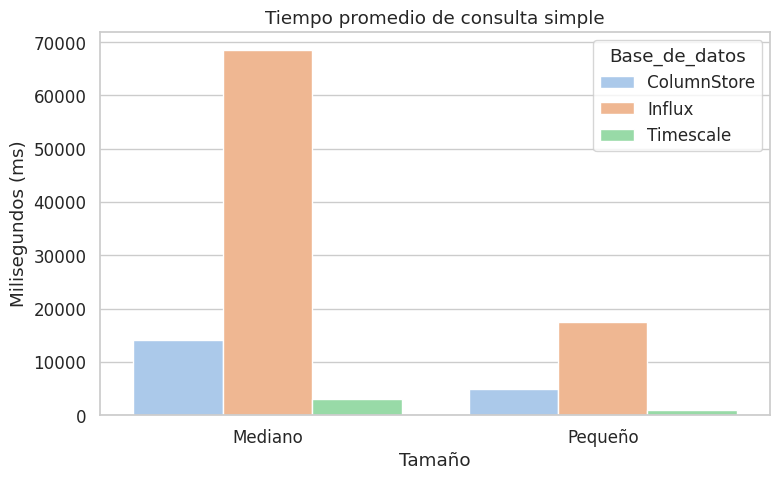

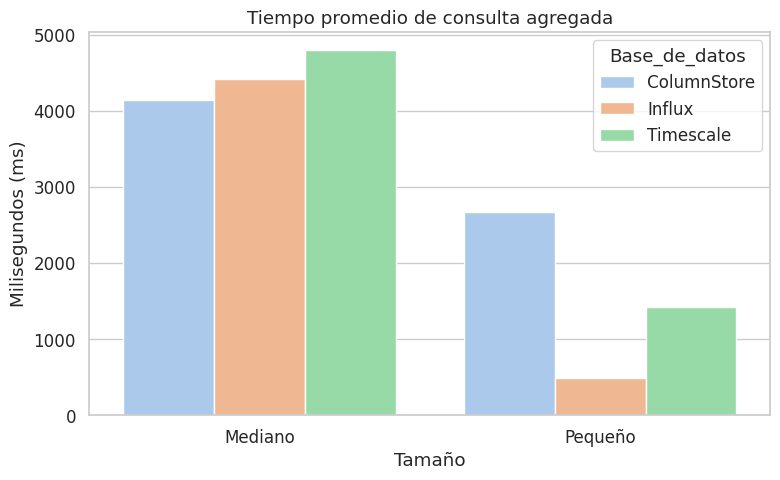

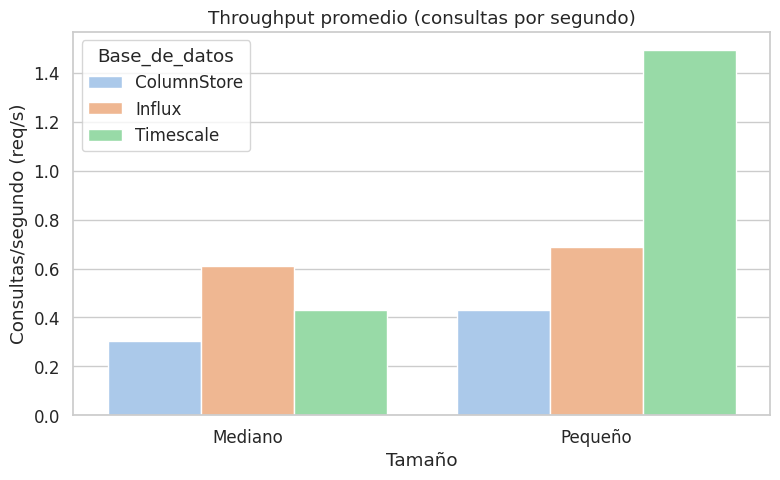

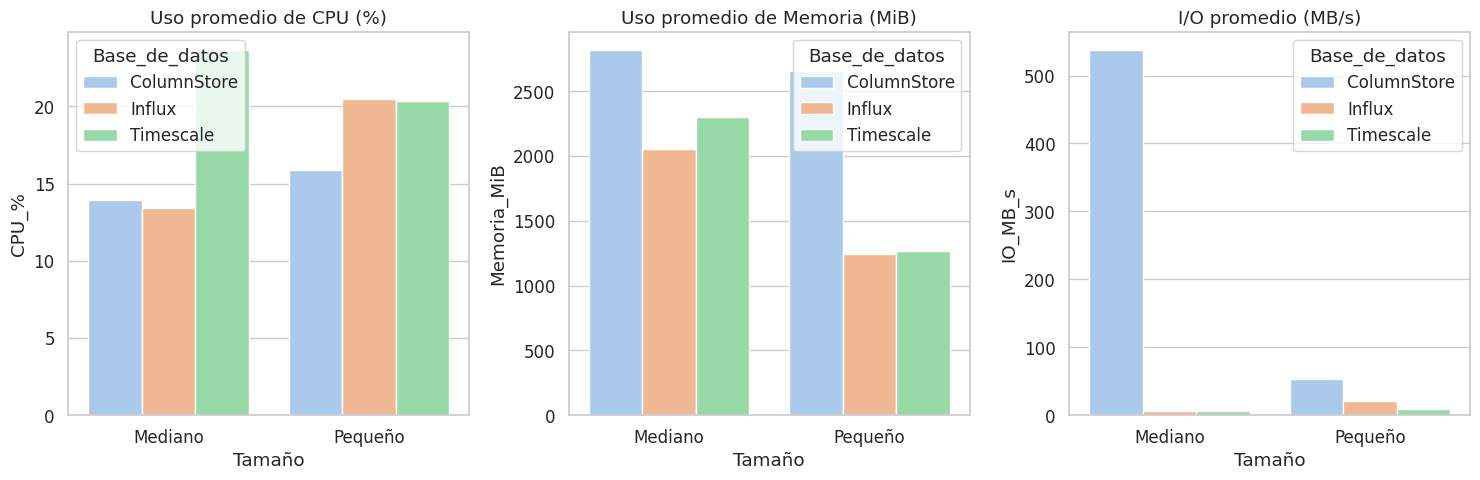

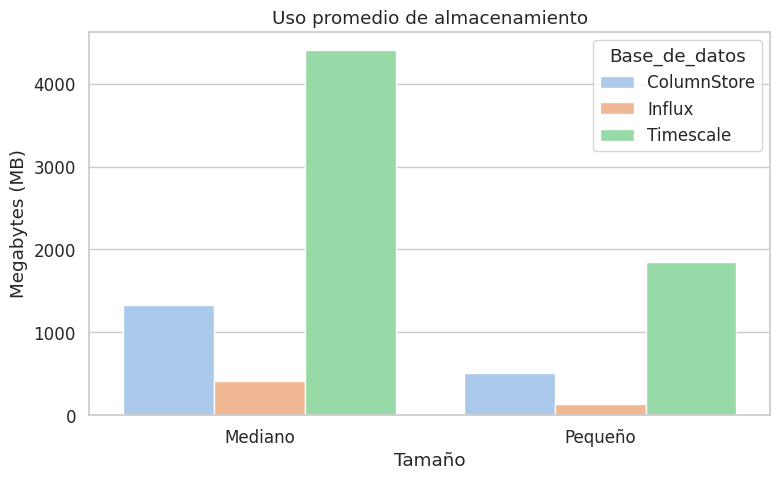

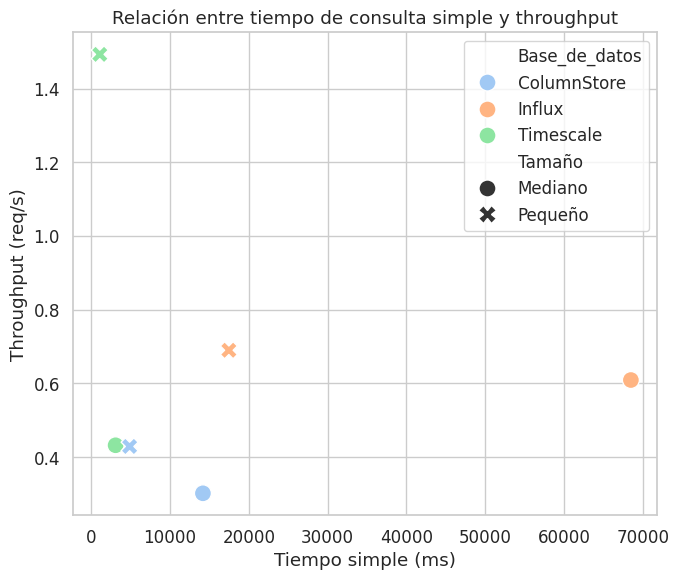

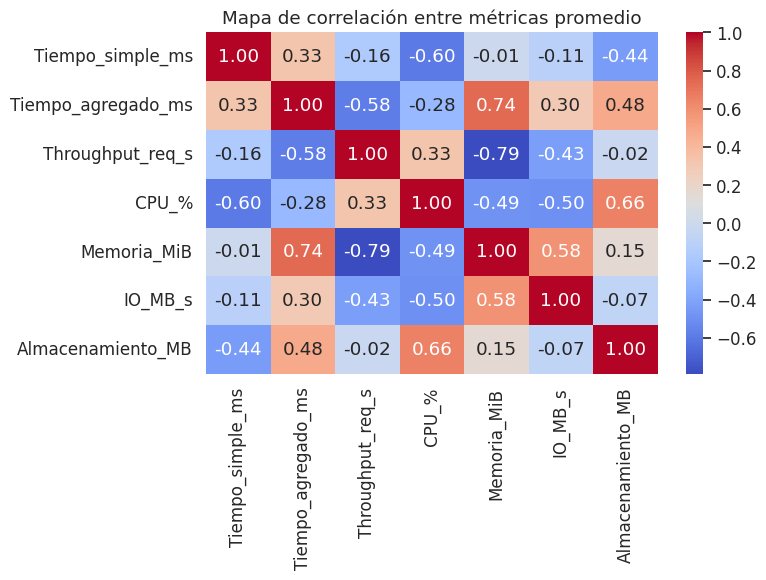

In [ ]:
# ===========================================================
# Análisis comparativo automático de bases de datos de series temporales
# (InfluxDB vs TimescaleDB vs MariaDB ColumnStore)
# ===========================================================
# Estructura esperada en Google Drive:
# /content/drive/MyDrive/results/
# ├── Small/
# │   ├── Influx/
# │   ├── Timescale/
# │   └── ColumnStore/
# └── Medium/
#     ├── Influx/
#     ├── Timescale/
#     └── ColumnStore/
# Cada subcarpeta contiene carpetas results_* con archivos de métricas .log.
# ===========================================================

import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="pastel", font_scale=1.1)

BASE_PATH = "/content/drive/MyDrive/Results/Stage2"
TAMANOS = ["Small", "Medium"]
BASES = ["Influx", "Timescale", "ColumnStore"]

# ===========================================================
# Funciones para leer archivos de métricas
# ===========================================================

def parsear_tiempo(path):
    """Lee los archivos de tiempo y devuelve la duración en milisegundos."""
    try:
        with open(path) as f:
            texto = f.read()
        m = re.search(r"real\s+(\d+)m([\d\.]+)s", texto)
        if m:
            return (int(m.group(1)) * 60 + float(m.group(2))) * 1000
    except:
        pass
    return np.nan

def parsear_throughput(path, consultas=10):
    """Calcula el throughput (consultas por segundo) según el tiempo total."""
    t = parsear_tiempo(path)
    return np.nan if np.isnan(t) else consultas / (t / 1000)

def parsear_cpu_mem(path):
    """Extrae el promedio de uso de CPU (%) y memoria (MiB) desde el log de 'top'."""
    cpu, mem = [], []
    try:
        with open(path) as f:
            for linea in f:
                if "Cpu(s)" in linea:
                    try:
                        cpu.append(float(re.findall(r"(\d+\.\d+)\s+us", linea)[0]))
                    except:
                        pass
                if "MiB Mem" in linea:
                    try:
                        mem.append(float(re.findall(r"(\d+\.\d+)\s+used", linea)[0]))
                    except:
                        pass
    except:
        pass
    return np.mean(cpu) if cpu else np.nan, np.mean(mem) if mem else np.nan

def parsear_iostat(path):
    """Promedia la actividad de lectura y escritura (MB/s) desde el log de iostat."""
    io_vals = []
    try:
        with open(path) as f:
            for linea in f:
                if re.match(r"\s*(sd[a-z]|nvme\d+n\d+|vd[a-z])", linea):
                    partes = linea.split()
                    try:
                        rmb = float(partes[5])
                        wmb = float(partes[9])
                        io_vals.append(rmb + wmb)
                    except (IndexError, ValueError):
                        continue
    except FileNotFoundError:
        pass
    return np.mean(io_vals) if io_vals else np.nan

def parsear_almacenamiento(path):
    """Lee el tamaño total de almacenamiento (en MB)."""
    try:
        with open(path) as f:
            valor = f.readline().split()[0]
            num = float(valor[:-1])
            unidad = valor[-1].upper()
            if unidad == "G":
                return num * 1024
            elif unidad == "M":
                return num
            else:
                return num / (1024 * 1024)
    except:
        pass
    return np.nan

def recolectar_resultados(base_dir, nombre_bd, etiqueta_tamano):
    """Recorre las ejecuciones de un motor y extrae las métricas desde los logs."""
    ejecuciones = []
    for carpeta in sorted(os.listdir(base_dir)):
        ruta = os.path.join(base_dir, carpeta)
        if not os.path.isdir(ruta):
            continue

        simple = parsear_tiempo(os.path.join(ruta, "time_simple.log"))
        agg = parsear_tiempo(os.path.join(ruta, "time_agg.log"))
        thr = parsear_throughput(os.path.join(ruta, "time_throughput.log"))
        cpu, mem = parsear_cpu_mem(os.path.join(ruta, "monitor_cpu_mem.log"))
        io = parsear_iostat(os.path.join(ruta, "monitor_disk.log"))
        stor = parsear_almacenamiento(os.path.join(ruta, "storage_usage.log"))

        ejecuciones.append({
            "Tamaño": etiqueta_tamano,
            "Base_de_datos": nombre_bd,
            "Ejecucion": carpeta,
            "Tiempo_simple_ms": simple,
            "Tiempo_agregado_ms": agg,
            "Throughput_req_s": thr,
            "CPU_%": cpu,
            "Memoria_MiB": mem,
            "IO_MB_s": io,
            "Almacenamiento_MB": stor
        })
    return pd.DataFrame(ejecuciones)

# ===========================================================
# Recolección de resultados
# ===========================================================

dataframes = []
for tamano in TAMANOS:
    for bd in BASES:
        carpeta = f"{BASE_PATH}/{tamano}/{bd}/"
        if os.path.exists(carpeta):
            print(f"Leyendo resultados desde: {carpeta}")
            dataframes.append(recolectar_resultados(carpeta, bd, tamano))

df_todo = pd.concat(dataframes, ignore_index=True)

df_todo["Tamaño"] = df_todo["Tamaño"].replace({
    "Small": "Pequeño",
    "Medium": "Mediano"
})

promedios = df_todo.groupby(["Tamaño", "Base_de_datos"]).mean(numeric_only=True).reset_index()

print("\nPromedios de métricas por tamaño y base de datos:")
print(promedios)

# ===========================================================
# Generación de gráficos
# ===========================================================

OUT_DIR = f"{BASE_PATH}/Figures/"
os.makedirs(OUT_DIR, exist_ok=True)

# --- 1. Tiempo de consulta simple ---
plt.figure(figsize=(8,5))
sns.barplot(data=promedios, x="Tamaño", y="Tiempo_simple_ms", hue="Base_de_datos")
plt.title("Tiempo promedio de consulta simple")
plt.ylabel("Milisegundos (ms)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_tiempo_simple_por_tamano.png", dpi=300)

# --- 2. Tiempo de consulta agregada ---
plt.figure(figsize=(8,5))
sns.barplot(data=promedios, x="Tamaño", y="Tiempo_agregado_ms", hue="Base_de_datos")
plt.title("Tiempo promedio de consulta agregada")
plt.ylabel("Milisegundos (ms)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_tiempo_agregado_por_tamano.png", dpi=300)

# --- 3. Throughput (consultas/segundo) ---
plt.figure(figsize=(8,5))
sns.barplot(data=promedios, x="Tamaño", y="Throughput_req_s", hue="Base_de_datos")
plt.title("Throughput promedio (consultas por segundo)")
plt.ylabel("Consultas/segundo (req/s)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_throughput_por_tamano.png", dpi=300)

# --- 4. Uso de CPU, Memoria e I/O ---
metricas = ["CPU_%", "Memoria_MiB", "IO_MB_s"]
titulos = ["Uso promedio de CPU (%)", "Uso promedio de Memoria (MiB)", "I/O promedio (MB/s)"]

fig, ejes = plt.subplots(1, 3, figsize=(15,5))
for i, m in enumerate(metricas):
    sns.barplot(data=promedios, x="Tamaño", y=m, hue="Base_de_datos", ax=ejes[i])
    ejes[i].set_title(titulos[i])
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_cpu_mem_io_por_tamano.png", dpi=300)

# --- 5. Uso de almacenamiento ---
plt.figure(figsize=(8,5))
sns.barplot(data=promedios, x="Tamaño", y="Almacenamiento_MB", hue="Base_de_datos")
plt.title("Uso promedio de almacenamiento")
plt.ylabel("Megabytes (MB)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_almacenamiento_por_tamano.png", dpi=300)

# --- 6. Relación entre tiempo simple y throughput ---
plt.figure(figsize=(7,6))
sns.scatterplot(data=promedios, x="Tiempo_simple_ms", y="Throughput_req_s",
                hue="Base_de_datos", style="Tamaño", s=150)
plt.title("Relación entre tiempo de consulta simple y throughput")
plt.xlabel("Tiempo simple (ms)")
plt.ylabel("Throughput (req/s)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_relacion_tiempo_vs_throughput.png", dpi=300)

# --- 7. Mapa de correlación entre métricas ---
corr = promedios.select_dtypes("number").corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de correlación entre métricas promedio")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_correlacion_metricas.png", dpi=300)

ruta_csv = f"{BASE_PATH}/comparacion_todas_bases.csv"
promedios.to_csv(ruta_csv, index=False)

# ===========================================================
# Guardar CSV
# ===========================================================

print("\nArchivo CSV de resumen guardado en:", ruta_csv)
print("Gráficos guardados en:", OUT_DIR)

### **Script utilizado para generar el dataset de tamaño *determinado* en `.lp`**

In [ ]:
#!/bin/bash
# =============================================================
# Script: generate_air_sensors_lp_TAMANO.sh
# Descripción: Genera un dataset sintético de aproximadamente TAMANO
#              en formato InfluxDB Line Protocol con timestamps únicos.
#
# Estructura de datos:
#   airSensors,sensor_id=TLMxxxx temperature=...,humidity=...,co=... timestamp
# =============================================================

# --- CONFIGURACIÓN BÁSICA ---
OUTPUT_FILE="air_sensors_TAMANO.lp"    # Nombre del archivo de salida
NUM_SENSORS=1                          # Número de sensores simulados
POINTS_PER_SENSOR=1                    # Puntos por sensor
START_TIMESTAMP=1609459200000000000    # 2021-01-01T00:00:00Z en nanosegundos
TIME_STEP=1000000000                   # Intervalo de 1 segundo (en ns)

# --- CÁLCULO DE TAMAÑO ESTIMADO ---
TOTAL_POINTS=$((NUM_SENSORS * POINTS_PER_SENSOR))
echo "Generando $TOTAL_POINTS puntos (~TAMANO esperado)..."

# --- LIMPIEZA DE ARCHIVO ANTERIOR ---
rm -f "$OUTPUT_FILE"

# --- GENERACIÓN DEL DATASET ---
awk -v sensors=$NUM_SENSORS \
    -v points=$POINTS_PER_SENSOR \
    -v start_ts=$START_TIMESTAMP \
    -v step=$TIME_STEP '
BEGIN {
    srand(42)                     # Fija semilla para reproducibilidad
    ts = start_ts
    for (s = 0; s < sensors; s++) {
        sensor_id = sprintf("TLM%04d", s)   # ID de sensor: TLM0000, TLM0001, ...
        for (i = 0; i < points; i++) {
            # Valores simulados dentro de rangos definidos
            temp = 60 + rand() * 20       # Temperatura: 60–80
            hum  = 30 + rand() * 40       # Humedad: 30–70
            co   = 0.3 + rand() * 0.4     # CO: 0.3–0.7

            # Escribe la línea en formato Line Protocol
            printf("airSensors,sensor_id=%s temperature=%.6f,humidity=%.6f,co=%.6f %d\n",
                   sensor_id, temp, hum, co, ts + i*step)
        }

        # Avanza el timestamp base para el siguiente sensor
        ts += points * step
    }
}' > "$OUTPUT_FILE"

# --- RESUMEN DE SALIDA ---
echo "Dataset generado en: $OUTPUT_FILE"
echo "Tamaño aproximado:"
ls -lh "$OUTPUT_FILE"
echo "Primeras líneas del archivo:"
head -n 3 "$OUTPUT_FILE"
echo "Últimas líneas del archivo:"
tail -n 3 "$OUTPUT_FILE"

### **Script utilizado para convertir de `.lp` a `.csv`**

In [ ]:
#!/usr/bin/env python3
# =============================================================
# Script: lp_to_csv.py
# Descripción: Convierte datos en formato InfluxDB Line Protocol
#              a un archivo CSV compatible con TimescaleDB.
#
# Ejemplo de línea de entrada:
#   airSensors,sensor_id=TLM0000 temperature=69.59,humidity=42.90,co=0.45 1609459200000000000
# Resultado esperado en CSV:
#   time,sensor_id,temperature,humidity,co
#   2021-01-01T00:00:00+00:00,TLM0000,69.59,42.90,0.45
# =============================================================

import csv
from datetime import datetime, timezone

# --- CONFIGURACIÓN DE ARCHIVOS ---
input_file = "air_sensors_TAMANO.lp"     # Archivo de entrada en formato Line Protocol
output_file = "air_sensors_TAMANO.csv"   # Archivo de salida en formato CSV

# --- PROCESAMIENTO PRINCIPAL ---
with open(input_file, "r") as fin, open(output_file, "w", newline="") as fout:
    writer = csv.writer(fout)

    # Escribir encabezados compatibles con TimescaleDB
    writer.writerow(["time", "sensor_id", "temperature", "humidity", "co"])

    line_count = 0   # Contador total de líneas leídas
    written = 0      # Contador de líneas válidas escritas en el CSV

    # Leer línea por línea del archivo .lp
    for line in fin:
        line_count += 1
        line = line.strip()
        if not line or line.startswith("#"):
            continue  # Saltar líneas vacías o comentarios

        try:
            # Separar partes: medición + tags / campos / timestamp
            parts = line.split(" ")
            if len(parts) != 3:
                continue  # Saltar líneas incompletas o mal formateadas

            measurement_and_tags, fields_part, timestamp = parts

            # --- Extraer el tag sensor_id ---
            tags = measurement_and_tags.split(",")
            sensor_id = None
            for t in tags[1:]:
                if t.startswith("sensor_id="):
                    sensor_id = t.split("=")[1]
                    break

            # --- Extraer los campos (key=value) ---
            field_dict = {}
            for field in fields_part.split(","):
                key, val = field.split("=")
                field_dict[key] = float(val)

            # --- Convertir timestamp (ns → ISO8601 UTC) ---
            # TimescaleDB
            ts = datetime.fromtimestamp(int(timestamp) / 1e9, tz=timezone.utc).isoformat()

            # MariaDB ColumnStore
            # ts = datetime.utcfromtimestamp(int(timestamp) / 1e9).strftime("%Y-%m-%d %H:%M:%S")


            # --- Escribir fila en el archivo CSV ---
            writer.writerow([
                ts,
                sensor_id,
                field_dict.get("temperature", ""),
                field_dict.get("humidity", ""),
                field_dict.get("co", "")
            ])
            written += 1

        except Exception:
            # Si ocurre un error (formato inválido, campo faltante, etc.), se omite la línea
            continue

# --- RESUMEN DE CONVERSIÓN ---
print(f"Conversión completada: {output_file}")
print(f"Líneas procesadas: {line_count}")
print(f"Líneas válidas escritas: {written}")

---
### **Script utilizado para obtener las métricas en InfluxDB con el tamaño determinado**
---

In [ ]:
#!/bin/bash
# =============================================================
# Script: run_influx_test.sh
# Descripción: Prueba de rendimiento para InfluxDB,
#              estructurada igual que la de TimescaleDB.
#
# Uso:
#   ./run_influx_test.sh [LIMITE]
# Ejemplo:
#   ./run_influx_test.sh 1000000
# =============================================================

# --- CONFIGURACIÓN BÁSICA ---
BUCKET="influx_bucket_TAMANO"                # Nombre del bucket en InfluxDB
MEASUREMENT="airSensors"                    # Medición a consultar
FIELD="temperature"                         # Campo usado para promediar
CONTAINER="stoic_keller"                    # Nombre del contenedor Docker
RESULT_DIR="TAMANO/Influx/results_$(date +%Y%m%d_%H%M%S)"  # Carpeta de resultados con timestamp
mkdir -p "$RESULT_DIR"                      # Crea carpeta si no existe

echo "============================================"
echo "   INICIANDO PRUEBA InfluxDB"
echo "   Resultados se guardarán en: $RESULT_DIR"
echo "============================================"

# --- PARÁMETRO DE LÍMITE ---
LIMIT_POINTS=$1
if [ -n "$LIMIT_POINTS" ]; then
  LIMIT_CLAUSE="|> limit(n:$LIMIT_POINTS)"  # Aplica límite si se pasa como parámetro
  echo "Usando límite: $LIMIT_POINTS filas"
else
  LIMIT_CLAUSE=""                           # Si no hay parámetro, lee todo el dataset
  echo "Sin límite definido (se leerá todo el dataset)"
fi
echo "--------------------------------------------"

# --- LIMPIEZA DE CACHÉ Y REINICIO DEL CONTENEDOR ---
echo "Limpiando caché y reiniciando InfluxDB..."
sudo sync                                   # Sincroniza escritura en disco
echo 3 | sudo tee /proc/sys/vm/drop_caches > /dev/null  # Limpia cachés del sistema
docker restart "$CONTAINER" > /dev/null     # Reinicia el contenedor
sleep 10                                    # Espera a que el contenedor inicie correctamente

# --- MONITOREO DEL SISTEMA ---
echo "Iniciando monitores del sistema..."
top -d 1 -b > "$RESULT_DIR/monitor_cpu_mem.log" &  # Monitor CPU y memoria
TOP_PID=$!
iostat -xm 1 > "$RESULT_DIR/monitor_disk.log" &    # Monitor de disco
IOSTAT_PID=$!

# --- CONSULTA SIMPLE ---
echo "Ejecutando consulta simple..."
(time influx query "
from(bucket:\"$BUCKET\")
  |> range(start: 2021-01-01T00:00:00Z, stop: 2021-08-21T00:00:00Z)
  |> filter(fn:(r) => r._measurement == \"$MEASUREMENT\")
  |> group()
  $LIMIT_CLAUSE
" > /dev/null) 2> "$RESULT_DIR/time_simple.log"

# --- CONSULTA AGREGADA ---
echo "Ejecutando consulta agregada..."
(time influx query "
from(bucket:\"$BUCKET\")
  |> range(start: 2021-01-01T00:00:00Z, stop: 2021-08-21T00:00:00Z)
  |> filter(fn:(r) => r._measurement == \"$MEASUREMENT\")
  |> filter(fn:(r) => r._field == \"$FIELD\")
  |> group()
  |> aggregateWindow(every: 1h, fn: mean, createEmpty: false)
  |> yield(name: \"mean\")
" > /dev/null) 2> "$RESULT_DIR/time_agg.log"

# --- PRUEBA DE THROUGHPUT (10 CONSULTAS PARALELAS) ---
echo "Ejecutando prueba de throughput (10 consultas paralelas)..."
(time seq 10 | xargs -n1 -P10 bash -c \
  "influx query '
    from(bucket:\"$BUCKET\")
      |> range(start: 2021-01-01T00:00:00Z, stop: 2021-01-02T00:00:00Z)
      |> filter(fn:(r) => r._measurement == \"$MEASUREMENT\")
      |> filter(fn:(r) => r._field == \"$FIELD\")
      |> group()
      |> sort(columns:[\"_time\"], desc: false)
      $LIMIT_CLAUSE
      |> yield(name:\"throughput\")
  ' > /dev/null") \
  2> "$RESULT_DIR/time_throughput.log"

# --- MONITOREO DEL CONTENEDOR ---
echo "Capturando uso de recursos del contenedor..."
docker stats "$CONTAINER" --no-stream --format \
"table {{.CPUPerc}}\t{{.MemUsage}}\t{{.NetIO}}\t{{.BlockIO}}" > "$RESULT_DIR/monitor_docker.log"

# --- DETENER MONITORES ---
echo "Deteniendo monitores..."
kill "$TOP_PID" "$IOSTAT_PID" 2>/dev/null

# --- MEDICIÓN DE USO DE DISCO ---
echo "Midiendo uso de disco..."
sudo du -sh ~/Docker/data > "$RESULT_DIR/storage_usage.log" 2>/dev/null

# --- RESUMEN FINAL ---
echo "Prueba completada."
echo "Resultados guardados en: $RESULT_DIR"
echo "--------------------------------------------"
ls -1 "$RESULT_DIR"
echo "--------------------------------------------"

---
### **Script utilizado para obtener las métricas en TimescaleDB con el tamaño determinado**
---

In [ ]:
#!/bin/bash
# =============================================================
# Script: run_timescale_test.sh
# Descripción: Ejecuta un benchmark de rendimiento para TimescaleDB,
#              estructurado de forma equivalente a las pruebas usadas con InfluxDB.
#
# Uso:
#   ./run_timescale_test.sh [LIMITE]
# Ejemplo:
#   ./run_timescale_test.sh 100000
# =============================================================

# --- CONFIGURACIÓN BÁSICA ---
DB_NAME="timeseries"                               # Nombre de la base de datos
DB_USER="proyecto"                                 # Usuario de conexión
TABLE="air_sensors"                                # Tabla de datos
CONTAINER="timescaledb"                            # Nombre del contenedor Docker
RESULT_DIR="TAMANO/Timescale/results_$(date +%Y%m%d_%H%M%S)"  # Carpeta de resultados
mkdir -p "$RESULT_DIR"

echo "============================================"
echo "   INICIANDO PRUEBA TimescaleDB"
echo "   Resultados se guardarán en: $RESULT_DIR"
echo "============================================"

# --- PARÁMETRO DE LÍMITE ---
LIMIT_POINTS=$1
if [ -n "$LIMIT_POINTS" ]; then
  LIMIT_CLAUSE="LIMIT $LIMIT_POINTS"
  echo "Usando límite de: $LIMIT_POINTS filas"
else
  LIMIT_CLAUSE=""
  echo "Sin límite definido (leerá todo el rango disponible)"
fi
echo "--------------------------------------------"

# --- LIMPIEZA DE CACHÉ Y REINICIO DEL CONTENEDOR ---
echo "Limpiando caché y reiniciando TimescaleDB..."
sudo sync
echo 3 | sudo tee /proc/sys/vm/drop_caches > /dev/null
docker restart "$CONTAINER" > /dev/null
sleep 10

# --- MONITOREO DEL SISTEMA ---
echo "Iniciando monitores del sistema..."
top -d 1 -b > "$RESULT_DIR/monitor_cpu_mem.log" &   # Monitor de CPU y memoria
TOP_PID=$!
iostat -xm 1 > "$RESULT_DIR/monitor_disk.log" &     # Monitor de I/O de disco
IOSTAT_PID=$!

# --- CONSULTA SIMPLE ---
echo "Ejecutando consulta simple..."
(time sudo docker exec -i "$CONTAINER" psql -U "$DB_USER" -d "$DB_NAME" -c "
SELECT time, sensor_id, temperature
FROM $TABLE
ORDER BY time ASC
$LIMIT_CLAUSE;
" > /dev/null) 2> "$RESULT_DIR/time_simple.log"

# --- CONSULTA AGREGADA ---
echo "Ejecutando consulta agregada..."
(time sudo docker exec -i "$CONTAINER" psql -U "$DB_USER" -d "$DB_NAME" -c "
SELECT time_bucket('1 hour', time) AS bucket,
       AVG(temperature) AS mean_temperature
FROM $TABLE
GROUP BY bucket
ORDER BY bucket ASC;
" > /dev/null) 2> "$RESULT_DIR/time_agg.log"

# --- PRUEBA DE THROUGHPUT (10 CONSULTAS PARALELAS) ---
echo "Ejecutando prueba de throughput (10 consultas en paralelo)..."
(time seq 10 | xargs -n1 -P10 bash -c \
  "sudo docker exec -i $CONTAINER psql -U $DB_USER -d $DB_NAME -c \
  \"SELECT time, sensor_id, temperature FROM $TABLE ORDER BY time ASC $LIMIT_CLAUSE;\" > /dev/null") \
  2> "$RESULT_DIR/time_throughput.log"

# --- ESTADÍSTICAS DEL CONTENEDOR ---
echo "Capturando uso de recursos del contenedor..."
docker stats "$CONTAINER" --no-stream --format \
"table {{.CPUPerc}}\t{{.MemUsage}}\t{{.NetIO}}\t{{.BlockIO}}" > "$RESULT_DIR/monitor_docker.log"

# --- DETENER MONITORES ---
echo "Deteniendo monitores..."
kill "$TOP_PID" "$IOSTAT_PID" 2>/dev/null

# --- USO DE DISCO ---
echo "Midiendo uso de almacenamiento..."
sudo du -sh ~/Docker/tsdata > "$RESULT_DIR/storage_usage.log" 2>/dev/null

# --- RESUMEN FINAL ---
echo "Prueba completada."
echo "Resultados guardados en: $RESULT_DIR"
echo "--------------------------------------------"
ls -1 "$RESULT_DIR"
echo "--------------------------------------------"

---
### **Script utilizado para obtener las métricas en MariaDB ColumnStore con el tamaño determinado**
---

In [ ]:
#!/bin/bash
# =============================================================
# Script: run_columnstore_test.sh
# Descripción: Ejecuta consultas de rendimiento para MariaDB ColumnStore,
#              estructuradas de forma equivalente a las pruebas usadas con
#              InfluxDB y TimescaleDB.
#
# Uso:
#   ./run_columnstore_test.sh [LIMITE]
# Ejemplo:
#   ./run_columnstore_test.sh 100000
# =============================================================

# --- CONFIGURACIÓN BÁSICA ---
DB_NAME="timeseries"                             # Nombre de la base de datos
DB_USER="admin"                                  # Usuario de conexión
DB_PASS="C0lumnStore!"                           # Contraseña definida al crear el contenedor
TABLE="air_sensors"                              # Tabla de datos
CONTAINER="mcs1"                                 # Nombre del contenedor Docker
RESULT_DIR="TAMANO/ColumnStore/results_$(date +%Y%m%d_%H%M%S)"  # Carpeta de resultados
mkdir -p "$RESULT_DIR"

echo "============================================"
echo "   INICIANDO PRUEBA MariaDB ColumnStore"
echo "   Resultados se guardarán en: $RESULT_DIR"
echo "============================================"

# --- PARÁMETRO DE LÍMITE ---
LIMIT_POINTS=$1
if [ -n "$LIMIT_POINTS" ]; then
  LIMIT_CLAUSE="LIMIT $LIMIT_POINTS"
  echo "Usando límite de: $LIMIT_POINTS filas"
else
  LIMIT_CLAUSE=""
  echo "Sin límite definido (leerá todo el rango disponible)"
fi
echo "--------------------------------------------"

# --- LIMPIEZA DE CACHÉ Y REINICIO DEL CONTENEDOR ---
echo "Limpiando caché y reiniciando MariaDB ColumnStore..."
sudo sync
echo 3 | sudo tee /proc/sys/vm/drop_caches > /dev/null
sleep 10

# --- MONITOREO DEL SISTEMA ---
echo "Iniciando monitores del sistema..."
top -d 1 -b > "$RESULT_DIR/monitor_cpu_mem.log" &   # Monitor de CPU y memoria
TOP_PID=$!
iostat -xm 1 > "$RESULT_DIR/monitor_disk.log" &     # Monitor de I/O de disco
IOSTAT_PID=$!

# --- CONSULTA SIMPLE ---
echo "Ejecutando consulta simple..."
(time docker exec -i "$CONTAINER" mariadb -u "$DB_USER" -p"$DB_PASS" -D "$DB_NAME" -e "
SELECT time, sensor_id, temperature
FROM $TABLE
ORDER BY time ASC
$LIMIT_CLAUSE;
" > "$RESULT_DIR/time_simple.csv") 2> "$RESULT_DIR/time_simple.log"

# --- CONSULTA AGREGADA ---
echo "Ejecutando consulta agregada..."
(time docker exec -i "$CONTAINER" mariadb -u "$DB_USER" -p"$DB_PASS" -D "$DB_NAME" -e "
SELECT
  DATE_FORMAT(time, '%Y-%m-%d %H:00:00') AS bucket,
  AVG(temperature) AS mean_temperature
FROM $TABLE
GROUP BY bucket
ORDER BY bucket ASC;
" > /dev/null) 2> "$RESULT_DIR/time_agg.log"

# --- PRUEBA DE THROUGHPUT (10 CONSULTAS PARALELAS) ---
echo "Ejecutando prueba de throughput (10 consultas paralelas)..."
(time seq 10 | xargs -n1 -P10 bash -c \
  "docker exec -i $CONTAINER mariadb -u $DB_USER -p$DB_PASS -D $DB_NAME -e \
  \"SELECT time, sensor_id, temperature FROM $TABLE ORDER BY time ASC $LIMIT_CLAUSE;\" > /dev/null") \
  2> "$RESULT_DIR/time_throughput.log"

# --- ESTADÍSTICAS DEL CONTENEDOR ---
echo "Capturando uso de recursos del contenedor..."
docker stats "$CONTAINER" --no-stream --format \
"table {{.CPUPerc}}\t{{.MemUsage}}\t{{.NetIO}}\t{{.BlockIO}}" > "$RESULT_DIR/monitor_docker.log"

# --- DETENER MONITORES ---
echo "Deteniendo monitores..."
kill "$TOP_PID" "$IOSTAT_PID" 2>/dev/null

# --- USO DE DISCO ---
echo "Midiendo uso de almacenamiento..."
sudo du -sh $(docker inspect -f '{{ range .Mounts }}{{ if eq .Destination "/var/lib/mysql" }}{{ .Source }}{{ end }}{{ end }}' $CONTAINER) > "$RESULT_DIR/storage_usage.log" 2>/dev/null

# --- RESUMEN FINAL ---
echo "Prueba completada."
echo "Resultados guardados en: $RESULT_DIR"
echo "--------------------------------------------"
ls -1 "$RESULT_DIR"
echo "--------------------------------------------"